# End to End Deep Learning Project Using Simple RNN

In [1]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import datetime

from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing import sequence
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout, Input, SimpleRNN, GRU, Input
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, TensorBoard
from sklearn.model_selection import train_test_split
from keras import initializers


In [2]:
# Load the Imdb dataset

max_features= 10000 ## vocabulary size
(X_train,y_train),(X_test,y_test)= imdb.load_data(num_words=max_features)

print(f'Training data shape: {X_train.shape}, training labels shape: {y_train.shape}')
print(f'Testing data shape: {X_test.shape}, testing labels shape: {y_test.shape}')

Training data shape: (25000,), training labels shape: (25000,)
Testing data shape: (25000,), testing labels shape: (25000,)


In [3]:
X_train[0]


[1,
 14,
 22,
 16,
 43,
 530,
 973,
 1622,
 1385,
 65,
 458,
 4468,
 66,
 3941,
 4,
 173,
 36,
 256,
 5,
 25,
 100,
 43,
 838,
 112,
 50,
 670,
 2,
 9,
 35,
 480,
 284,
 5,
 150,
 4,
 172,
 112,
 167,
 2,
 336,
 385,
 39,
 4,
 172,
 4536,
 1111,
 17,
 546,
 38,
 13,
 447,
 4,
 192,
 50,
 16,
 6,
 147,
 2025,
 19,
 14,
 22,
 4,
 1920,
 4613,
 469,
 4,
 22,
 71,
 87,
 12,
 16,
 43,
 530,
 38,
 76,
 15,
 13,
 1247,
 4,
 22,
 17,
 515,
 17,
 12,
 16,
 626,
 18,
 2,
 5,
 62,
 386,
 12,
 8,
 316,
 8,
 106,
 5,
 4,
 2223,
 5244,
 16,
 480,
 66,
 3785,
 33,
 4,
 130,
 12,
 16,
 38,
 619,
 5,
 25,
 124,
 51,
 36,
 135,
 48,
 25,
 1415,
 33,
 6,
 22,
 12,
 215,
 28,
 77,
 52,
 5,
 14,
 407,
 16,
 82,
 2,
 8,
 4,
 107,
 117,
 5952,
 15,
 256,
 4,
 2,
 7,
 3766,
 5,
 723,
 36,
 71,
 43,
 530,
 476,
 26,
 400,
 317,
 46,
 7,
 4,
 2,
 1029,
 13,
 104,
 88,
 4,
 381,
 15,
 297,
 98,
 32,
 2071,
 56,
 26,
 141,
 6,
 194,
 7486,
 18,
 4,
 226,
 22,
 21,
 134,
 476,
 26,
 480,
 5,
 144,
 30,
 5535,
 18,

In [4]:
y_train[0]


np.int64(1)

In [5]:
## Inspect a sample review and its label

sample_review= X_train[0]
sample_label= y_train[0]


In [6]:
# Map word index to words
word_to_index= imdb.get_word_index()

word_to_index



{'fawn': 34701,
 'tsukino': 52006,
 'nunnery': 52007,
 'sonja': 16816,
 'vani': 63951,
 'woods': 1408,
 'spiders': 16115,
 'hanging': 2345,
 'woody': 2289,
 'trawling': 52008,
 "hold's": 52009,
 'comically': 11307,
 'localized': 40830,
 'disobeying': 30568,
 "'royale": 52010,
 "harpo's": 40831,
 'canet': 52011,
 'aileen': 19313,
 'acurately': 52012,
 "diplomat's": 52013,
 'rickman': 25242,
 'arranged': 6746,
 'rumbustious': 52014,
 'familiarness': 52015,
 "spider'": 52016,
 'hahahah': 68804,
 "wood'": 52017,
 'transvestism': 40833,
 "hangin'": 34702,
 'bringing': 2338,
 'seamier': 40834,
 'wooded': 34703,
 'bravora': 52018,
 'grueling': 16817,
 'wooden': 1636,
 'wednesday': 16818,
 "'prix": 52019,
 'altagracia': 34704,
 'circuitry': 52020,
 'crotch': 11585,
 'busybody': 57766,
 "tart'n'tangy": 52021,
 'burgade': 14129,
 'thrace': 52023,
 "tom's": 11038,
 'snuggles': 52025,
 'francesco': 29114,
 'complainers': 52027,
 'templarios': 52125,
 '272': 40835,
 '273': 52028,
 'zaniacs': 52130,

In [7]:
reverse_word_index= {value: key for key, value in word_to_index.items()}

reverse_word_index



{34701: 'fawn',
 52006: 'tsukino',
 52007: 'nunnery',
 16816: 'sonja',
 63951: 'vani',
 1408: 'woods',
 16115: 'spiders',
 2345: 'hanging',
 2289: 'woody',
 52008: 'trawling',
 52009: "hold's",
 11307: 'comically',
 40830: 'localized',
 30568: 'disobeying',
 52010: "'royale",
 40831: "harpo's",
 52011: 'canet',
 19313: 'aileen',
 52012: 'acurately',
 52013: "diplomat's",
 25242: 'rickman',
 6746: 'arranged',
 52014: 'rumbustious',
 52015: 'familiarness',
 52016: "spider'",
 68804: 'hahahah',
 52017: "wood'",
 40833: 'transvestism',
 34702: "hangin'",
 2338: 'bringing',
 40834: 'seamier',
 34703: 'wooded',
 52018: 'bravora',
 16817: 'grueling',
 1636: 'wooden',
 16818: 'wednesday',
 52019: "'prix",
 34704: 'altagracia',
 52020: 'circuitry',
 11585: 'crotch',
 57766: 'busybody',
 52021: "tart'n'tangy",
 14129: 'burgade',
 52023: 'thrace',
 11038: "tom's",
 52025: 'snuggles',
 29114: 'francesco',
 52027: 'complainers',
 52125: 'templarios',
 40835: '272',
 52028: '273',
 52130: 'zaniacs',

In [8]:
decoded_review= ' '.join([reverse_word_index.get(i -3, '?') for i in sample_review])

decoded_review

"? this film was just brilliant casting location scenery story direction everyone's really suited the part they played and you could just imagine being there robert ? is an amazing actor and now the same being director ? father came from the same scottish island as myself so i loved the fact there was a real connection with this film the witty remarks throughout the film were great it was just brilliant so much that i bought the film as soon as it was released for ? and would recommend it to everyone to watch and the fly fishing was amazing really cried at the end it was so sad and you know what they say if you cry at a film it must have been good and this definitely was also ? to the two little boy's that played the ? of norman and paul they were just brilliant children are often left out of the ? list i think because the stars that play them all grown up are such a big profile for the whole film but these children are amazing and should be praised for what they have done don't you th

In [9]:
max_length= 500

X_train= sequence.pad_sequences(X_train, maxlen=max_length)
X_test= sequence.pad_sequences(X_test, maxlen=max_length)

X_train[0]



array([   0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,   

The IMDB dataset provided by Keras contains movie reviews that have already been preprocessed into Bag-of-Words format, where each word is represented by an integer index based on a predefined vocabulary size of 10,000. Along with the dataset, a dictionary mapping of words to their corresponding indices is provided, which makes it possible to decode the reviews back into their textual form.

Before the data can be used as input for a neural network, the sequence lengths must be standardized. This is accomplished using the pad_sequences method, where the maximum sequence length is set to 500. As a result, all reviews are either truncated or padded to ensure uniform shape, making them suitable for processing in the model pipeline.

# Train Simple RNN

## Test

In [10]:
tf.keras.backend.clear_session()
tf.random.set_seed(42)

In [11]:
initializer_1 = initializers.HeNormal(seed=42) # "glorot_Normal"
initializer_2 = initializers.GlorotNormal(seed=42)
initializer_3 = initializers.LecunNormal(seed=42)

In [12]:
model= Sequential()
model.add(Embedding(max_features, 128, input_length=max_length, input_shape=X_train.shape[1:]))
model.add(SimpleRNN(128, return_sequences=True,activation="tanh", kernel_initializer="glorot_uniform"))
model.add(SimpleRNN(128, return_sequences=False,activation="tanh", kernel_initializer="glorot_uniform"))
model.add(Dense(1, activation='sigmoid'))


c:\Users\Rondon\Documents\1. Python Starter\16.krish_IA_Udemy\04.02.deep_learning_4_nlp\.venv\Lib\site-packages\keras\src\layers\core\embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(
c:\Users\Rondon\Documents\1. Python Starter\16.krish_IA_Udemy\04.02.deep_learning_4_nlp\.venv\Lib\site-packages\keras\src\layers\core\embedding.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [13]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 500, 128)       │     1,280,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ (None, 500, 128)       │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_1 (SimpleRNN)        │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,345,921 (5.13 MB)

 Trainable params: 1,345,921 (5.13 MB)

 Non-trainable params: 0 (0.00 B)

In [14]:
## Set Early Stopping

early_stopping= EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)


In [15]:
## Set up the TensorBoard callback
log_dir = "logs/fit/" + datetime.datetime.now().strftime("%Y%m%d-%H%M%S")
tensorboard_callback = TensorBoard(log_dir=log_dir, histogram_freq=1)

In [16]:
Optimizer= Adam(learning_rate=0.001)

model.compile(loss='binary_crossentropy', optimizer=Optimizer, metrics=['accuracy'])



In [17]:

history= model.fit(X_train, y_train, epochs=500, batch_size=256, validation_split=0.2, callbacks=[early_stopping, tensorboard_callback], verbose=1)



Epoch 1/500
79/79 ━━━━━━━━━━━━━━━━━━━━ 39s 483ms/step - accuracy: 0.5121 - loss: 0.6979 - val_accuracy: 0.5998 - val_loss: 0.6599
Epoch 2/500
79/79 ━━━━━━━━━━━━━━━━━━━━ 39s 491ms/step - accuracy: 0.6853 - loss: 0.6034 - val_accuracy: 0.6782 - val_loss: 0.6272
Epoch 3/500
79/79 ━━━━━━━━━━━━━━━━━━━━ 39s 490ms/step - accuracy: 0.8653 - loss: 0.3187 - val_accuracy: 0.5986 - val_loss: 0.8261
Epoch 4/500
79/79 ━━━━━━━━━━━━━━━━━━━━ 39s 498ms/step - accuracy: 0.8132 - loss: 0.4112 - val_accuracy: 0.6440 - val_loss: 0.7767
Epoch 5/500
79/79 ━━━━━━━━━━━━━━━━━━━━ 39s 490ms/step - accuracy: 0.9170 - loss: 0.2018 - val_accuracy: 0.6354 - val_loss: 1.0877
Epoch 6/500
79/79 ━━━━━━━━━━━━━━━━━━━━ 38s 487ms/step - accuracy: 0.9355 - loss: 0.1561 - val_accuracy: 0.6262 - val_loss: 1.4193
Epoch 7/500
79/79 ━━━━━━━━━━━━━━━━━━━━ 38s 487ms/step - accuracy: 0.9353 - loss: 0.1613 - val_accuracy: 0.6434 - val_loss: 1.3960
Epoch 8/500
79/79 ━━━━━━━━━━━━━━━━━━━━ 38s 488ms/step - accuracy: 0.9646 - loss: 0.0900 - 

In [18]:
## Load tensorboard
%load_ext tensorboard
%tensorboard --logdir=logs\fit\20250421-161321

ERROR: Failed to launch TensorBoard (exited with 1).
Contents of stderr:
Failed to canonicalize script path

In [19]:
model.evaluate(X_test, y_test)


782/782 ━━━━━━━━━━━━━━━━━━━━ 17s 21ms/step - accuracy: 0.6664 - loss: 0.6377


[0.6332429051399231, 0.6690000295639038]

In [20]:
#model.save('pickle/simple_rnn_best_model.h5')


# RNN

initializer_1 = initializers.HeNormal(seed=42) 

initializer_2 = initializers.GlorotNormal(seed=42)

initializer_3 = initializers.LecunNormal(seed=42)

## HE 

In [21]:
tf.keras.backend.clear_session()
tf.random.set_seed(42)

In [22]:
RNN_HE= Sequential()
RNN_HE.add(Embedding(max_features, 128, input_length=max_length, input_shape=X_train.shape[1:]))
RNN_HE.add(SimpleRNN(128, return_sequences=True,activation="relu", kernel_initializer=initializer_1))
RNN_HE.add(SimpleRNN(128, return_sequences=False,activation="relu", kernel_initializer=initializer_1))
RNN_HE.add(Dense(1, activation='sigmoid'))

RNN_HE.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 500, 128)       │     1,280,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ (None, 500, 128)       │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_1 (SimpleRNN)        │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,345,921 (5.13 MB)

 Trainable params: 1,345,921 (5.13 MB)

 Non-trainable params: 0 (0.00 B)

In [23]:
early_stopping= EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

log_dir = "logs/fit/" + datetime.datetime.now().strftime("%Y%m%d-%H%M%S")
tensorboard_callback = TensorBoard(log_dir=log_dir, histogram_freq=1)

In [24]:
Optimizer= Adam(learning_rate=0.001)

RNN_HE.compile(loss='binary_crossentropy', 
               optimizer=Optimizer, 
               metrics=['accuracy'])

In [25]:

history_RNN_HE= RNN_HE.fit(X_train, y_train, 
                           epochs=500, 
                           batch_size=256, 
                           validation_split=0.2, 
                           callbacks=[early_stopping], 
                           verbose=1)


Epoch 1/500
79/79 ━━━━━━━━━━━━━━━━━━━━ 31s 372ms/step - accuracy: 0.5636 - loss: 0.6701 - val_accuracy: 0.6760 - val_loss: 0.5919
Epoch 2/500
79/79 ━━━━━━━━━━━━━━━━━━━━ 28s 354ms/step - accuracy: 0.7614 - loss: 0.5024 - val_accuracy: 0.7836 - val_loss: 0.5304
Epoch 3/500
79/79 ━━━━━━━━━━━━━━━━━━━━ 28s 356ms/step - accuracy: 0.8353 - loss: 0.3738 - val_accuracy: 0.8208 - val_loss: 0.5193
Epoch 4/500
79/79 ━━━━━━━━━━━━━━━━━━━━ 28s 353ms/step - accuracy: 0.9000 - loss: 0.2527 - val_accuracy: 0.7712 - val_loss: 0.5389
Epoch 5/500
79/79 ━━━━━━━━━━━━━━━━━━━━ 28s 356ms/step - accuracy: 0.9191 - loss: 0.2093 - val_accuracy: 0.7692 - val_loss: 0.6053
Epoch 6/500
79/79 ━━━━━━━━━━━━━━━━━━━━ 29s 362ms/step - accuracy: 0.9490 - loss: 0.1421 - val_accuracy: 0.7414 - val_loss: 0.6738
Epoch 7/500
79/79 ━━━━━━━━━━━━━━━━━━━━ 29s 361ms/step - accuracy: 0.9549 - loss: 0.1262 - val_accuracy: 0.7212 - val_loss: 0.8019
Epoch 8/500
79/79 ━━━━━━━━━━━━━━━━━━━━ 28s 358ms/step - accuracy: 0.9607 - loss: 0.1096 - 

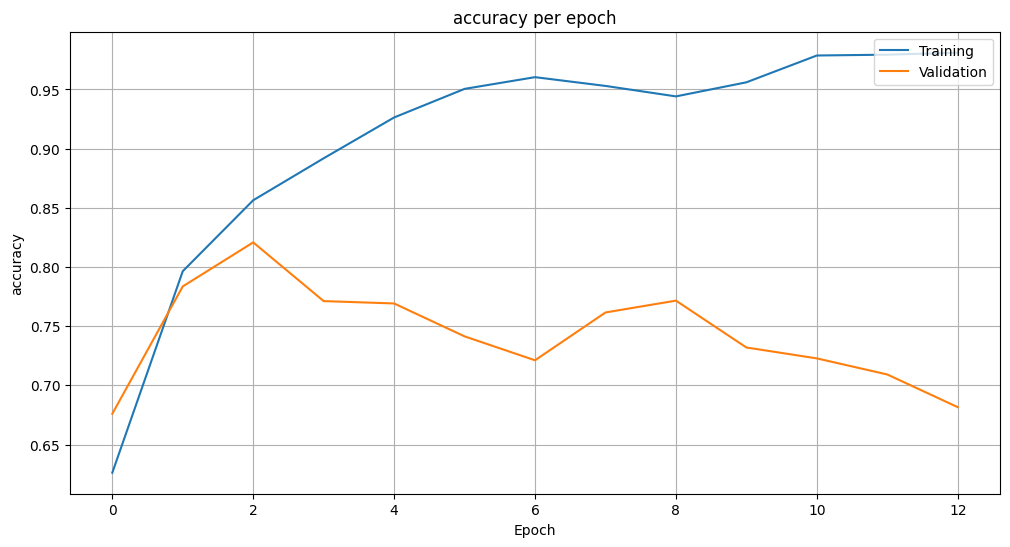

In [26]:
plt.figure(figsize=(12, 6))
plt.plot(history_RNN_HE.history['accuracy'])
plt.plot(history_RNN_HE.history['val_accuracy'])
plt.title('accuracy per epoch')
plt.ylabel('accuracy')
plt.xlabel('Epoch')
plt.legend(['Training', 'Validation'], loc='upper right')
plt.grid()
plt.show()

In [27]:
RNN_HE.evaluate(X_test, y_test)


782/782 ━━━━━━━━━━━━━━━━━━━━ 15s 19ms/step - accuracy: 0.8233 - loss: 0.5117


[0.5073693990707397, 0.8231599926948547]

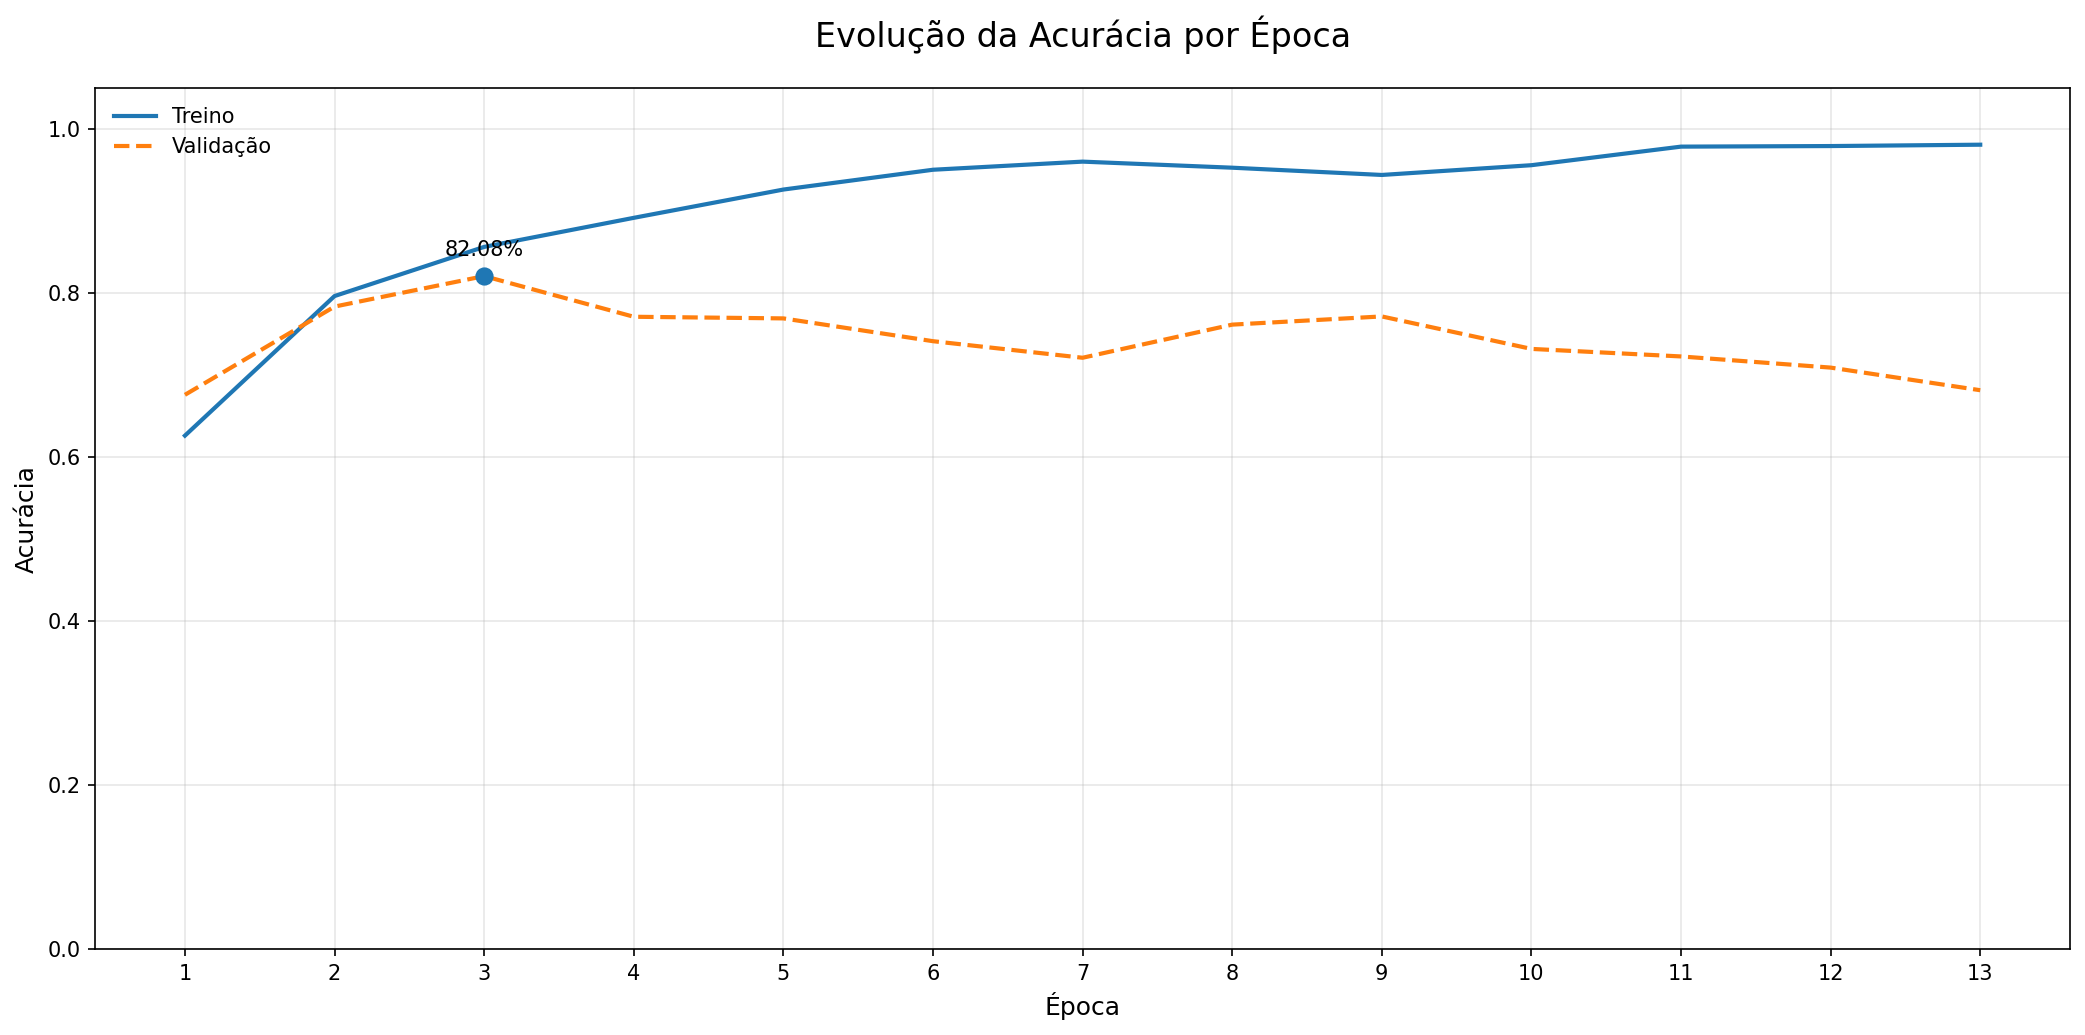

In [28]:
# ─── DADOS ──────────────────────────────────────────────────────────────────────
train_acc = history_RNN_HE.history['accuracy']
val_acc   = history_RNN_HE.history['val_accuracy']
epochs    = range(1, len(train_acc) + 1)

# ─── FIGURA ─────────────────────────────────────────────────────────────────────
plt.figure(figsize=(14, 7), dpi=150)

# Curva de treino
plt.plot(epochs, train_acc,
         label='Treino',
         linewidth=2)

# Curva de validação
plt.plot(epochs, val_acc,
         label='Validação',
         linewidth=2,
         linestyle='--')

# ─── REALCES ÚTEIS ──────────────────────────────────────────────────────────────
# Aponta a melhor época na validação
best_ep   = max(range(len(val_acc)), key=val_acc.__getitem__)
best_val  = val_acc[best_ep]
plt.scatter(best_ep + 1, best_val, s=60, zorder=5)
plt.text(best_ep + 1, best_val + 0.02,
         f'{best_val:.2%}',
         ha='center', va='bottom', fontsize=10)

# ─── ESTILO GERAL ───────────────────────────────────────────────────────────────
plt.title('Evolução da Acurácia por Época', fontsize=16, pad=20)
plt.xlabel('Época', fontsize=12)
plt.ylabel('Acurácia', fontsize=12)
plt.xticks(epochs)              # mostra todas as épocas no eixo-x
plt.ylim(0, 1.05)               # garante visibilidade até 100 %
plt.grid(alpha=0.3)             # grid suave
plt.legend(frameon=False)       # sem moldura no legend
plt.tight_layout()              # encaixa tudo

plt.show()

## GLorot

In [29]:
tf.keras.backend.clear_session()
tf.random.set_seed(42)

In [30]:
RNN_GL= Sequential()
RNN_GL.add(Embedding(max_features, 128, input_length=max_length, input_shape=X_train.shape[1:]))
RNN_GL.add(SimpleRNN(128, return_sequences=True,activation="tanh", kernel_initializer=initializer_2))
RNN_GL.add(SimpleRNN(128, return_sequences=False,activation="tanh", kernel_initializer=initializer_2))
RNN_GL.add(Dense(1, activation='sigmoid'))

RNN_GL.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 500, 128)       │     1,280,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ (None, 500, 128)       │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_1 (SimpleRNN)        │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,345,921 (5.13 MB)

 Trainable params: 1,345,921 (5.13 MB)

 Non-trainable params: 0 (0.00 B)

In [31]:
early_stopping= EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

In [32]:
Optimizer= Adam(learning_rate=0.001)

RNN_GL.compile(loss='binary_crossentropy', 
               optimizer=Optimizer, 
               metrics=['accuracy'])

In [33]:
history_RNN_GL= RNN_GL.fit(X_train, y_train, 
                           epochs=500, 
                           batch_size=256, 
                           validation_split=0.2, 
                           callbacks=[early_stopping], 
                           verbose=1)

Epoch 1/500
79/79 ━━━━━━━━━━━━━━━━━━━━ 30s 371ms/step - accuracy: 0.5187 - loss: 0.7001 - val_accuracy: 0.5778 - val_loss: 0.6546
Epoch 2/500
79/79 ━━━━━━━━━━━━━━━━━━━━ 29s 371ms/step - accuracy: 0.6766 - loss: 0.5871 - val_accuracy: 0.7980 - val_loss: 0.4569
Epoch 3/500
79/79 ━━━━━━━━━━━━━━━━━━━━ 29s 372ms/step - accuracy: 0.7214 - loss: 0.5643 - val_accuracy: 0.6040 - val_loss: 0.6671
Epoch 4/500
79/79 ━━━━━━━━━━━━━━━━━━━━ 30s 378ms/step - accuracy: 0.6774 - loss: 0.5999 - val_accuracy: 0.6796 - val_loss: 0.5858
Epoch 5/500
79/79 ━━━━━━━━━━━━━━━━━━━━ 30s 378ms/step - accuracy: 0.7145 - loss: 0.5617 - val_accuracy: 0.6790 - val_loss: 0.5842
Epoch 6/500
79/79 ━━━━━━━━━━━━━━━━━━━━ 30s 377ms/step - accuracy: 0.7850 - loss: 0.4650 - val_accuracy: 0.6698 - val_loss: 0.5906
Epoch 7/500
79/79 ━━━━━━━━━━━━━━━━━━━━ 30s 379ms/step - accuracy: 0.7700 - loss: 0.4771 - val_accuracy: 0.7038 - val_loss: 0.5907
Epoch 8/500
79/79 ━━━━━━━━━━━━━━━━━━━━ 30s 379ms/step - accuracy: 0.8313 - loss: 0.3811 - 

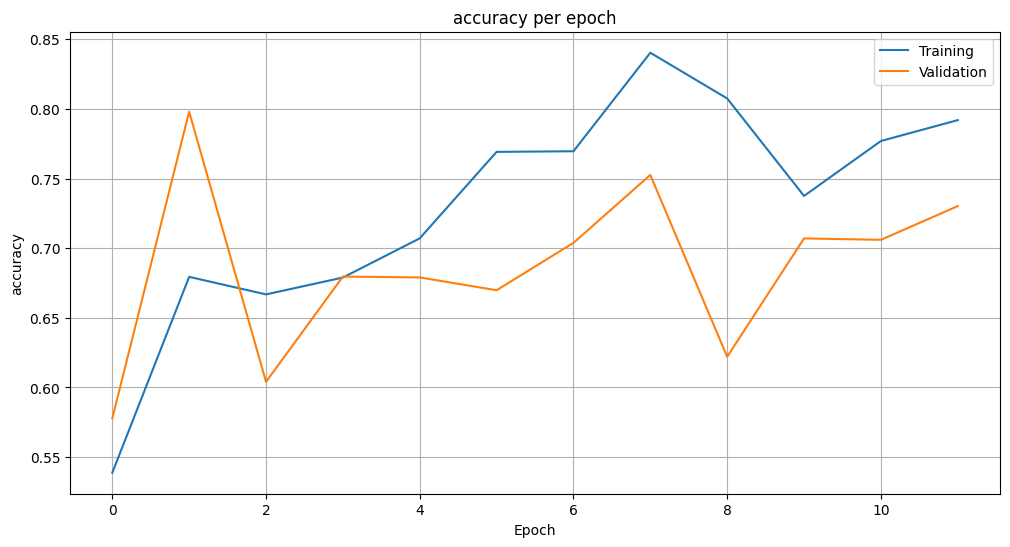

In [34]:
plt.figure(figsize=(12, 6))
plt.plot(history_RNN_GL.history['accuracy'])
plt.plot(history_RNN_GL.history['val_accuracy'])
plt.title('accuracy per epoch')
plt.ylabel('accuracy')
plt.xlabel('Epoch')
plt.legend(['Training', 'Validation'], loc='upper right')
plt.grid()
plt.show()

In [35]:
RNN_GL.evaluate(X_test, y_test)

782/782 ━━━━━━━━━━━━━━━━━━━━ 17s 22ms/step - accuracy: 0.7965 - loss: 0.4521


[0.4504038989543915, 0.7978000044822693]

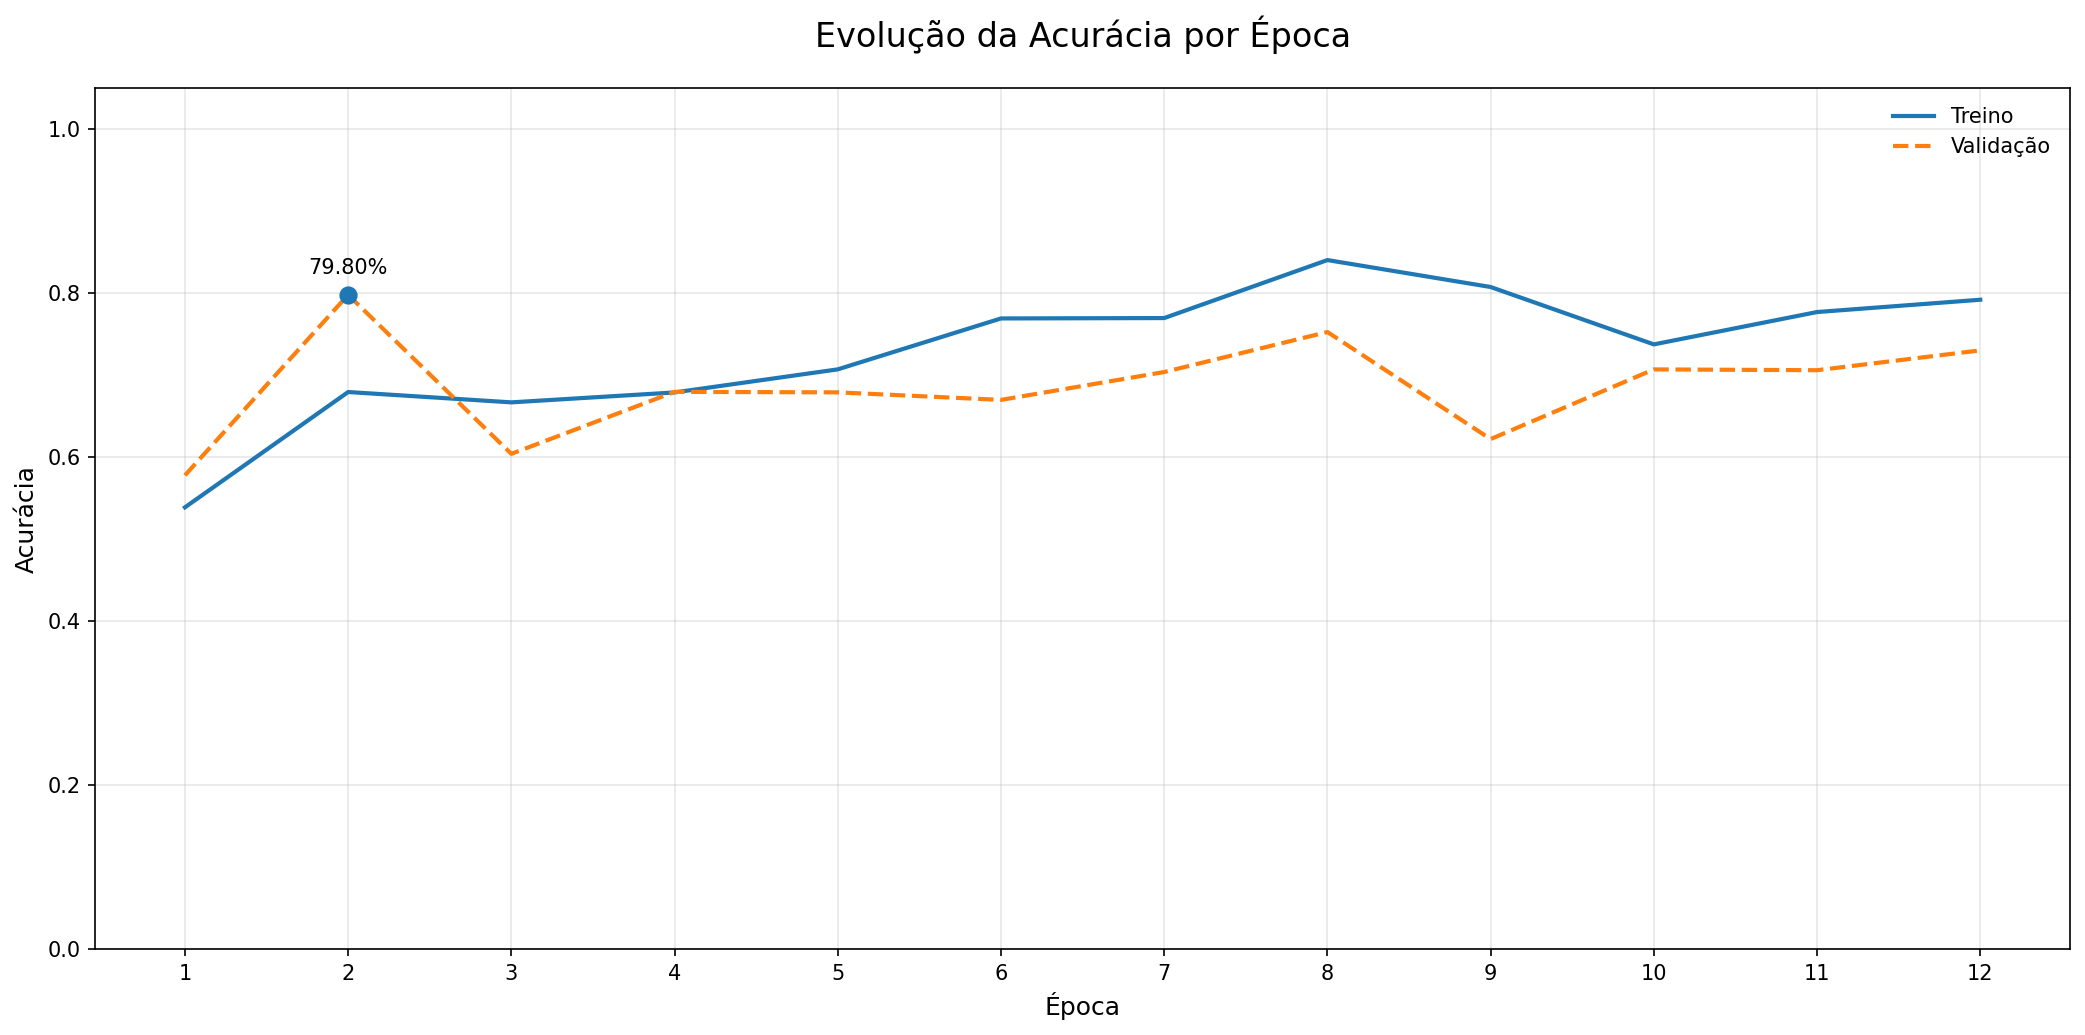

In [36]:
# ─── DADOS ──────────────────────────────────────────────────────────────────────
train_acc = history_RNN_GL.history['accuracy']
val_acc   = history_RNN_GL.history['val_accuracy']
epochs    = range(1, len(train_acc) + 1)

# ─── FIGURA ─────────────────────────────────────────────────────────────────────
plt.figure(figsize=(14, 7), dpi=150)

# Curva de treino
plt.plot(epochs, train_acc,
         label='Treino',
         linewidth=2)

# Curva de validação
plt.plot(epochs, val_acc,
         label='Validação',
         linewidth=2,
         linestyle='--')

# ─── REALCES ÚTEIS ──────────────────────────────────────────────────────────────
# Aponta a melhor época na validação
best_ep   = max(range(len(val_acc)), key=val_acc.__getitem__)
best_val  = val_acc[best_ep]
plt.scatter(best_ep + 1, best_val, s=60, zorder=5)
plt.text(best_ep + 1, best_val + 0.02,
         f'{best_val:.2%}',
         ha='center', va='bottom', fontsize=10)

# ─── ESTILO GERAL ───────────────────────────────────────────────────────────────
plt.title('Evolução da Acurácia por Época', fontsize=16, pad=20)
plt.xlabel('Época', fontsize=12)
plt.ylabel('Acurácia', fontsize=12)
plt.xticks(epochs)              # mostra todas as épocas no eixo-x
plt.ylim(0, 1.05)               # garante visibilidade até 100 %
plt.grid(alpha=0.3)             # grid suave
plt.legend(frameon=False)       # sem moldura no legend
plt.tight_layout()              # encaixa tudo

plt.show()


## LeCun

In [37]:
tf.keras.backend.clear_session()
tf.random.set_seed(42)

In [38]:
RNN_LE= Sequential()
RNN_LE.add(Embedding(max_features, 128, input_length=max_length, input_shape=X_train.shape[1:]))
RNN_LE.add(SimpleRNN(128, return_sequences=True,activation="tanh", kernel_initializer=initializer_3))
RNN_LE.add(SimpleRNN(128, return_sequences=False,activation="tanh", kernel_initializer=initializer_3))
RNN_LE.add(Dense(1, activation='sigmoid'))

RNN_LE.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 500, 128)       │     1,280,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ (None, 500, 128)       │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_1 (SimpleRNN)        │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,345,921 (5.13 MB)

 Trainable params: 1,345,921 (5.13 MB)

 Non-trainable params: 0 (0.00 B)

In [39]:
early_stopping= EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
Optimizer= Adam(learning_rate=0.001)

RNN_LE.compile(loss='binary_crossentropy', 
               optimizer=Optimizer, 
               metrics=['accuracy'])

In [40]:
history_RNN_LE= RNN_LE.fit(X_train, y_train, 
                           epochs=500, 
                           batch_size=256, 
                           validation_split=0.2, 
                           callbacks=[early_stopping], 
                           verbose=1)

Epoch 1/500
79/79 ━━━━━━━━━━━━━━━━━━━━ 30s 360ms/step - accuracy: 0.5142 - loss: 0.7014 - val_accuracy: 0.5862 - val_loss: 0.6723
Epoch 2/500
79/79 ━━━━━━━━━━━━━━━━━━━━ 29s 361ms/step - accuracy: 0.6341 - loss: 0.6384 - val_accuracy: 0.6890 - val_loss: 0.5723
Epoch 3/500
79/79 ━━━━━━━━━━━━━━━━━━━━ 28s 358ms/step - accuracy: 0.7919 - loss: 0.4433 - val_accuracy: 0.7130 - val_loss: 0.6233
Epoch 4/500
79/79 ━━━━━━━━━━━━━━━━━━━━ 28s 359ms/step - accuracy: 0.9192 - loss: 0.2020 - val_accuracy: 0.7488 - val_loss: 0.6871
Epoch 5/500
79/79 ━━━━━━━━━━━━━━━━━━━━ 28s 357ms/step - accuracy: 0.9655 - loss: 0.0958 - val_accuracy: 0.7318 - val_loss: 0.8821
Epoch 6/500
79/79 ━━━━━━━━━━━━━━━━━━━━ 28s 358ms/step - accuracy: 0.9766 - loss: 0.0620 - val_accuracy: 0.7074 - val_loss: 1.0098
Epoch 7/500
79/79 ━━━━━━━━━━━━━━━━━━━━ 28s 356ms/step - accuracy: 0.9908 - loss: 0.0287 - val_accuracy: 0.7330 - val_loss: 1.0180
Epoch 8/500
79/79 ━━━━━━━━━━━━━━━━━━━━ 28s 359ms/step - accuracy: 0.9961 - loss: 0.0148 - 

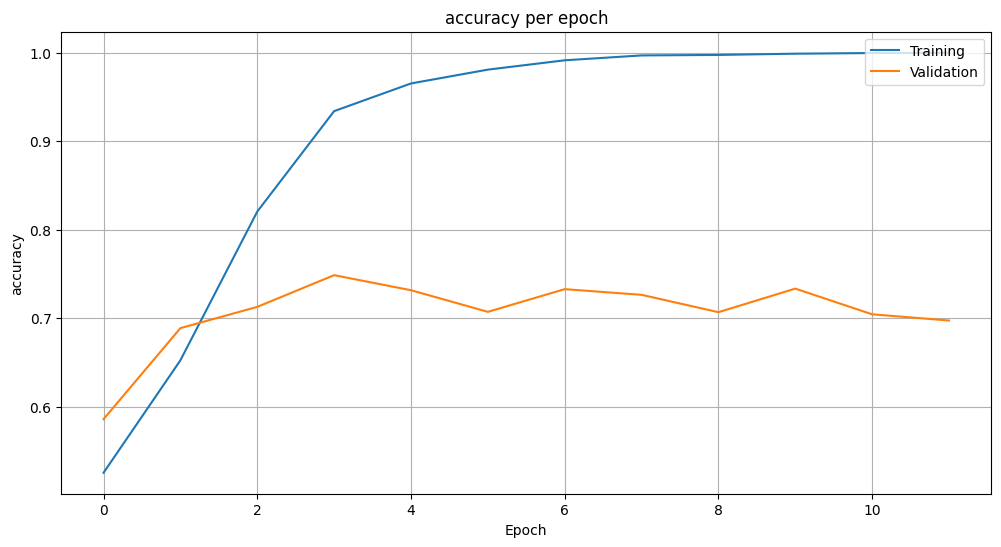

In [41]:
plt.figure(figsize=(12, 6))
plt.plot(history_RNN_LE.history['accuracy'])
plt.plot(history_RNN_LE.history['val_accuracy'])
plt.title('accuracy per epoch')
plt.ylabel('accuracy')
plt.xlabel('Epoch')
plt.legend(['Training', 'Validation'], loc='upper right')
plt.grid()
plt.show()

In [42]:
RNN_LE.evaluate(X_test, y_test)

782/782 ━━━━━━━━━━━━━━━━━━━━ 17s 22ms/step - accuracy: 0.6899 - loss: 0.5720


[0.5673037171363831, 0.693120002746582]

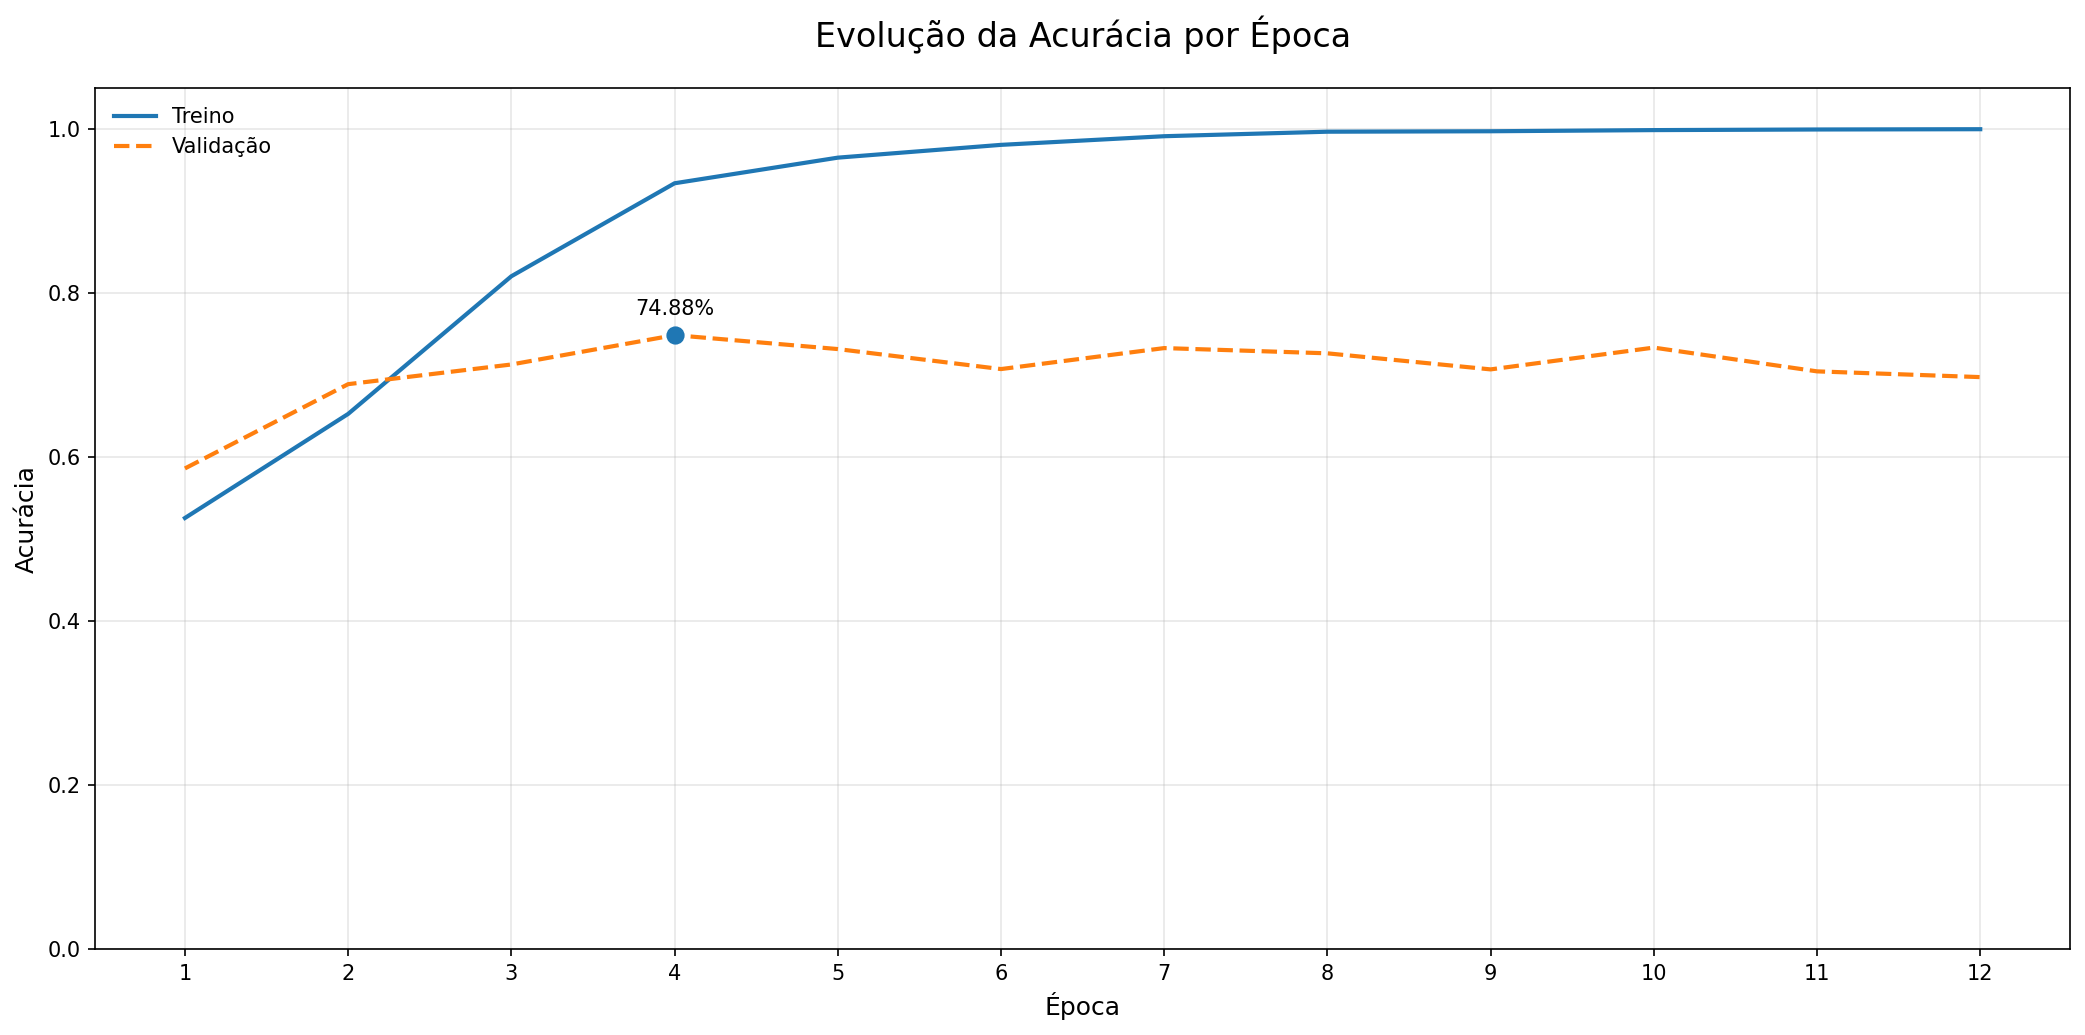

In [43]:


# ─── DADOS ──────────────────────────────────────────────────────────────────────
train_acc = history_RNN_LE.history['accuracy']
val_acc   = history_RNN_LE.history['val_accuracy']
epochs    = range(1, len(train_acc) + 1)

# ─── FIGURA ─────────────────────────────────────────────────────────────────────
plt.figure(figsize=(14, 7), dpi=150)

# Curva de treino
plt.plot(epochs, train_acc,
         label='Treino',
         linewidth=2)

# Curva de validação
plt.plot(epochs, val_acc,
         label='Validação',
         linewidth=2,
         linestyle='--')

# ─── REALCES ÚTEIS ──────────────────────────────────────────────────────────────
# Aponta a melhor época na validação
best_ep   = max(range(len(val_acc)), key=val_acc.__getitem__)
best_val  = val_acc[best_ep]
plt.scatter(best_ep + 1, best_val, s=60, zorder=5)
plt.text(best_ep + 1, best_val + 0.02,
         f'{best_val:.2%}',
         ha='center', va='bottom', fontsize=10)

# ─── ESTILO GERAL ───────────────────────────────────────────────────────────────
plt.title('Evolução da Acurácia por Época', fontsize=16, pad=20)
plt.xlabel('Época', fontsize=12)
plt.ylabel('Acurácia', fontsize=12)
plt.xticks(epochs)              # mostra todas as épocas no eixo-x
plt.ylim(0, 1.05)               # garante visibilidade até 100 %
plt.grid(alpha=0.3)             # grid suave
plt.legend(frameon=False)       # sem moldura no legend
plt.tight_layout()              # encaixa tudo

plt.show()


# LSTM

## HE 

In [44]:
tf.keras.backend.clear_session()
tf.random.set_seed(42)

In [45]:
LSTM_HE= Sequential()
LSTM_HE.add(Embedding(max_features, 128, input_length=max_length, input_shape=X_train.shape[1:]))
LSTM_HE.add(LSTM(64, return_sequences=True,activation="relu", kernel_initializer=initializer_1))
LSTM_HE.add(LSTM(64, return_sequences=False,activation="relu", kernel_initializer=initializer_1))
LSTM_HE.add(Dense(1, activation='sigmoid'))

LSTM_HE.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 500, 128)       │     1,280,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 500, 64)        │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,362,497 (5.20 MB)

 Trainable params: 1,362,497 (5.20 MB)

 Non-trainable params: 0 (0.00 B)

In [46]:
early_stopping= EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

Optimizer= Adam(learning_rate=0.001)

LSTM_HE.compile(loss='binary_crossentropy', 
               optimizer=Optimizer, 
               metrics=['accuracy'])

In [47]:
history_LSTM_HE= LSTM_HE.fit(X_train, y_train, 
                           epochs=500, 
                           batch_size=256, 
                           validation_split=0.2, 
                           callbacks=[early_stopping], 
                           verbose=1)

Epoch 1/500
79/79 ━━━━━━━━━━━━━━━━━━━━ 92s 1s/step - accuracy: 0.5520 - loss: nan - val_accuracy: 0.5062 - val_loss: nan
Epoch 2/500
79/79 ━━━━━━━━━━━━━━━━━━━━ 95s 1s/step - accuracy: 0.4999 - loss: nan - val_accuracy: 0.5062 - val_loss: nan
Epoch 3/500
79/79 ━━━━━━━━━━━━━━━━━━━━ 100s 1s/step - accuracy: 0.4999 - loss: nan - val_accuracy: 0.5062 - val_loss: nan
Epoch 4/500
79/79 ━━━━━━━━━━━━━━━━━━━━ 106s 1s/step - accuracy: 0.4999 - loss: nan - val_accuracy: 0.5062 - val_loss: nan
Epoch 5/500
79/79 ━━━━━━━━━━━━━━━━━━━━ 106s 1s/step - accuracy: 0.4999 - loss: nan - val_accuracy: 0.5062 - val_loss: nan
Epoch 6/500
79/79 ━━━━━━━━━━━━━━━━━━━━ 107s 1s/step - accuracy: 0.4999 - loss: nan - val_accuracy: 0.5062 - val_loss: nan
Epoch 7/500
79/79 ━━━━━━━━━━━━━━━━━━━━ 109s 1s/step - accuracy: 0.4999 - loss: nan - val_accuracy: 0.5062 - val_loss: nan
Epoch 8/500
79/79 ━━━━━━━━━━━━━━━━━━━━ 110s 1s/step - accuracy: 0.4999 - loss: nan - val_accuracy: 0.5062 - val_loss: nan
Epoch 9/500
79/79 ━━━━━━━━

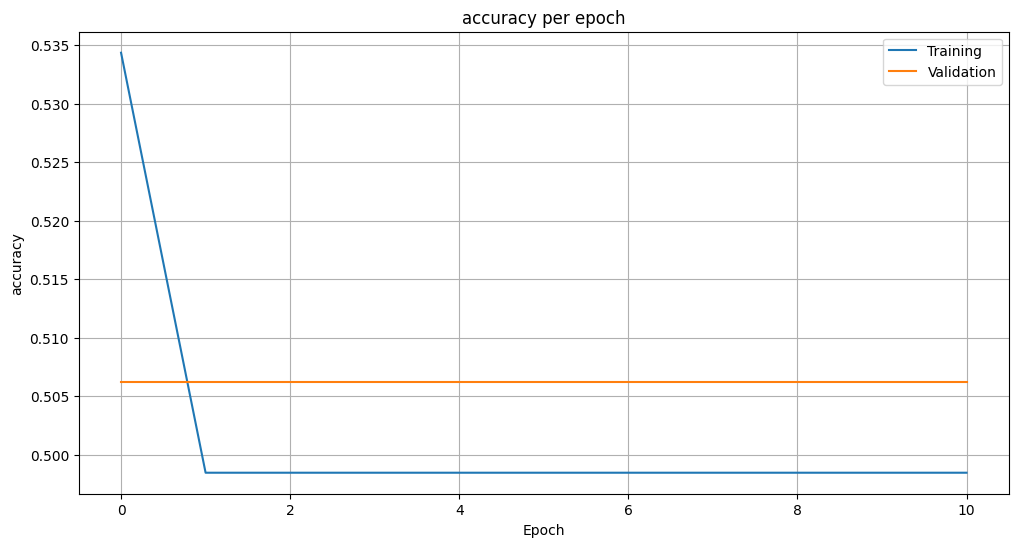

In [48]:
plt.figure(figsize=(12, 6))
plt.plot(history_LSTM_HE.history['accuracy'])
plt.plot(history_LSTM_HE.history['val_accuracy'])
plt.title('accuracy per epoch')
plt.ylabel('accuracy')
plt.xlabel('Epoch')
plt.legend(['Training', 'Validation'], loc='upper right')
plt.grid()
plt.show()

In [49]:
LSTM_HE.evaluate(X_test, y_test)

782/782 ━━━━━━━━━━━━━━━━━━━━ 55s 70ms/step - accuracy: 0.5073 - loss: nan


[nan, 0.5]

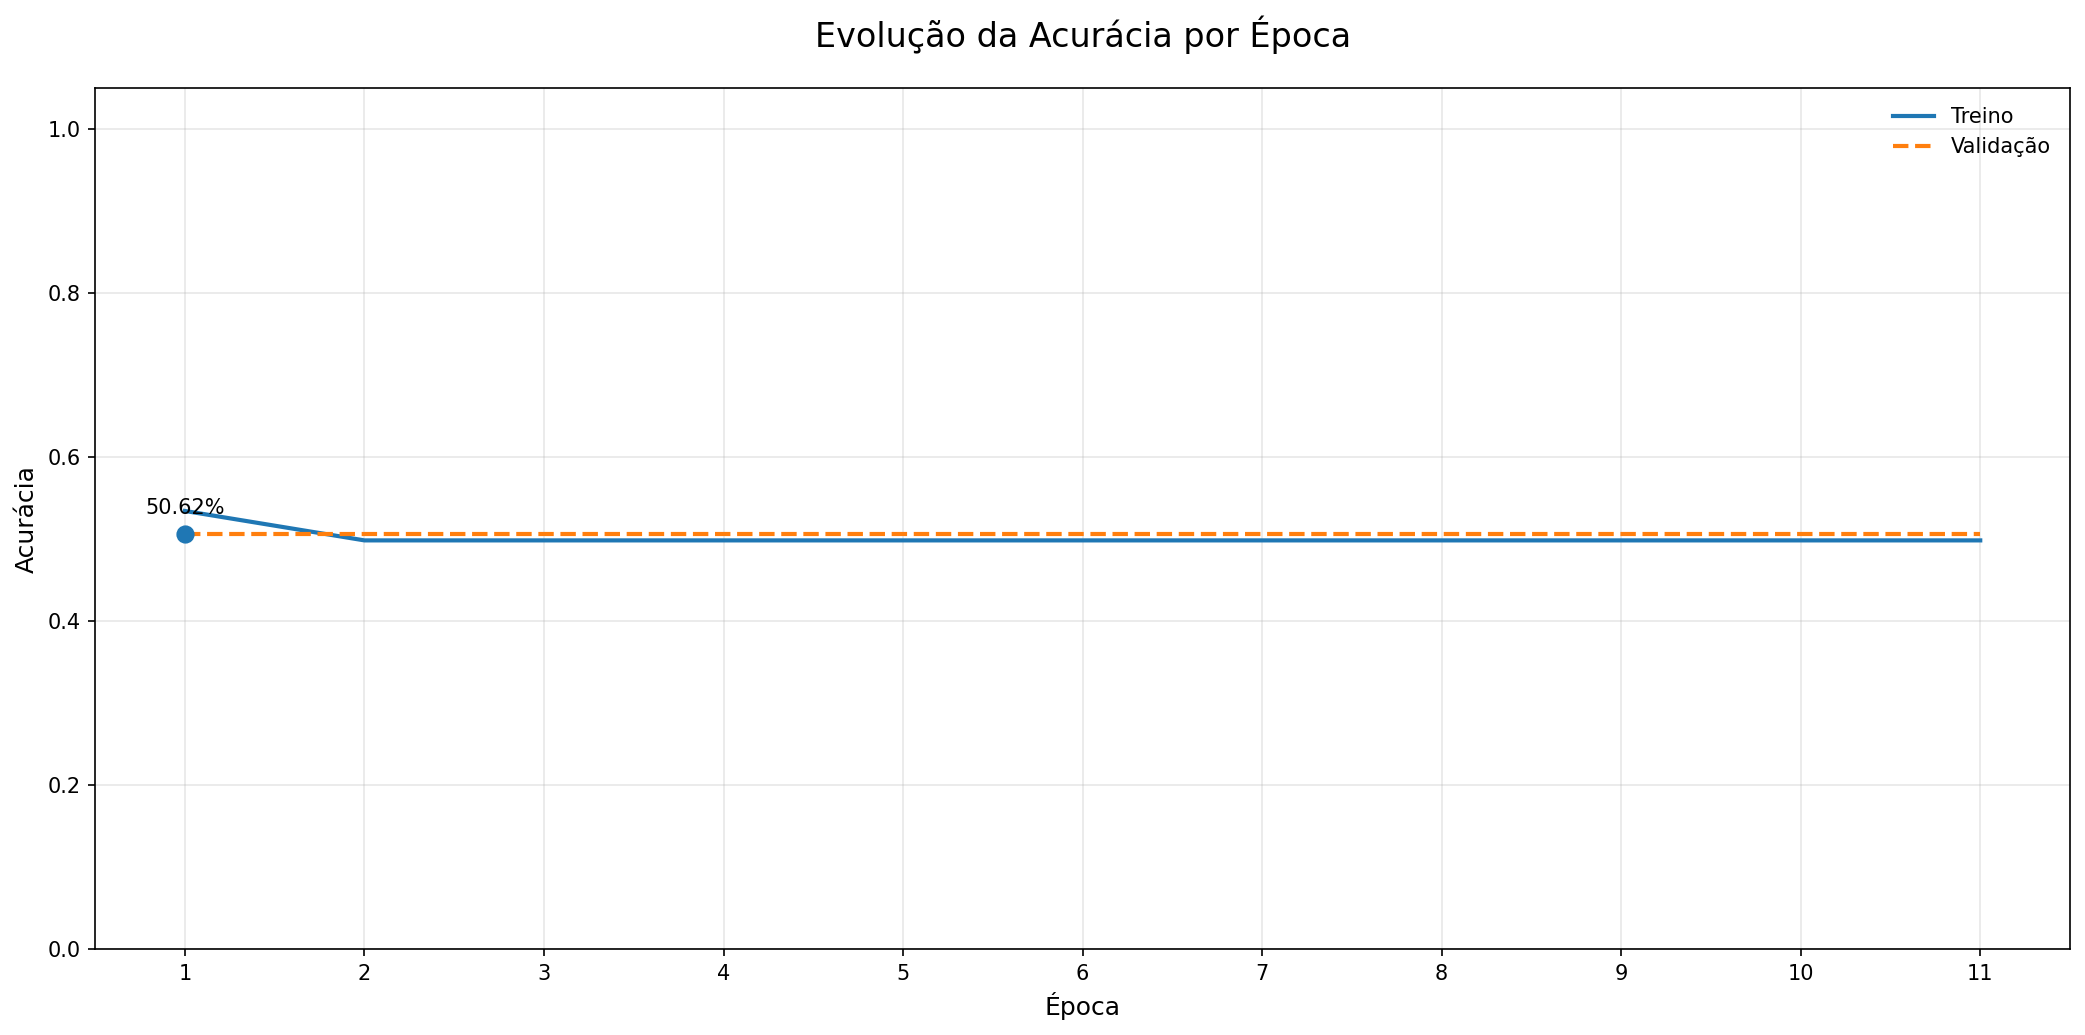

In [50]:
# ─── DADOS ──────────────────────────────────────────────────────────────────────
train_acc = history_LSTM_HE.history['accuracy']
val_acc   = history_LSTM_HE.history['val_accuracy']
epochs    = range(1, len(train_acc) + 1)

# ─── FIGURA ─────────────────────────────────────────────────────────────────────
plt.figure(figsize=(14, 7), dpi=150)

# Curva de treino
plt.plot(epochs, train_acc,
         label='Treino',
         linewidth=2)

# Curva de validação
plt.plot(epochs, val_acc,
         label='Validação',
         linewidth=2,
         linestyle='--')

# ─── REALCES ÚTEIS ──────────────────────────────────────────────────────────────
# Aponta a melhor época na validação
best_ep   = max(range(len(val_acc)), key=val_acc.__getitem__)
best_val  = val_acc[best_ep]
plt.scatter(best_ep + 1, best_val, s=60, zorder=5)
plt.text(best_ep + 1, best_val + 0.02,
         f'{best_val:.2%}',
         ha='center', va='bottom', fontsize=10)

# ─── ESTILO GERAL ───────────────────────────────────────────────────────────────
plt.title('Evolução da Acurácia por Época', fontsize=16, pad=20)
plt.xlabel('Época', fontsize=12)
plt.ylabel('Acurácia', fontsize=12)
plt.xticks(epochs)              # mostra todas as épocas no eixo-x
plt.ylim(0, 1.05)               # garante visibilidade até 100 %
plt.grid(alpha=0.3)             # grid suave
plt.legend(frameon=False)       # sem moldura no legend
plt.tight_layout()              # encaixa tudo

plt.show()


## GLorot

In [51]:
tf.keras.backend.clear_session()
tf.random.set_seed(42)

In [52]:
LSTM_GL= Sequential()
LSTM_GL.add(Embedding(max_features, 128, input_length=max_length, input_shape=X_train.shape[1:]))
LSTM_GL.add(LSTM(64, return_sequences=True,activation="tanh", kernel_initializer=initializer_2))
LSTM_GL.add(LSTM(64, return_sequences=False,activation="tanh", kernel_initializer=initializer_2))
LSTM_GL.add(Dense(1, activation='sigmoid'))

LSTM_GL.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 500, 128)       │     1,280,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 500, 64)        │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,362,497 (5.20 MB)

 Trainable params: 1,362,497 (5.20 MB)

 Non-trainable params: 0 (0.00 B)

In [53]:
early_stopping= EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
Optimizer= Adam(learning_rate=0.001)

LSTM_GL.compile(loss='binary_crossentropy', 
               optimizer=Optimizer, 
               metrics=['accuracy'])

In [54]:
history_LSTM_GL= LSTM_GL.fit(X_train, y_train, 
                           epochs=500, 
                           batch_size=256, 
                           validation_split=0.2, 
                           callbacks=[early_stopping], 
                           verbose=1)

Epoch 1/500
79/79 ━━━━━━━━━━━━━━━━━━━━ 106s 1s/step - accuracy: 0.6450 - loss: 0.6058 - val_accuracy: 0.8508 - val_loss: 0.3572
Epoch 2/500
79/79 ━━━━━━━━━━━━━━━━━━━━ 105s 1s/step - accuracy: 0.8677 - loss: 0.3132 - val_accuracy: 0.8516 - val_loss: 0.3777
Epoch 3/500
79/79 ━━━━━━━━━━━━━━━━━━━━ 104s 1s/step - accuracy: 0.9192 - loss: 0.2176 - val_accuracy: 0.8584 - val_loss: 0.4480
Epoch 4/500
79/79 ━━━━━━━━━━━━━━━━━━━━ 104s 1s/step - accuracy: 0.9324 - loss: 0.1841 - val_accuracy: 0.8468 - val_loss: 0.3625
Epoch 5/500
79/79 ━━━━━━━━━━━━━━━━━━━━ 105s 1s/step - accuracy: 0.9119 - loss: 0.2277 - val_accuracy: 0.8484 - val_loss: 0.3650
Epoch 6/500
79/79 ━━━━━━━━━━━━━━━━━━━━ 105s 1s/step - accuracy: 0.9407 - loss: 0.1627 - val_accuracy: 0.8472 - val_loss: 0.4065
Epoch 7/500
79/79 ━━━━━━━━━━━━━━━━━━━━ 104s 1s/step - accuracy: 0.9539 - loss: 0.1305 - val_accuracy: 0.8232 - val_loss: 0.5252
Epoch 8/500
79/79 ━━━━━━━━━━━━━━━━━━━━ 105s 1s/step - accuracy: 0.9320 - loss: 0.1737 - val_accuracy: 0.

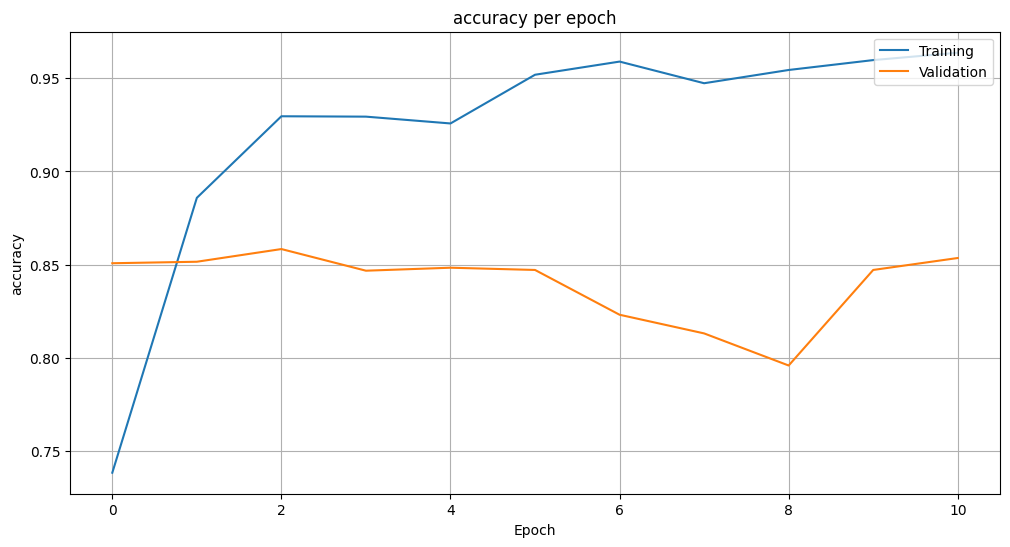

In [55]:
plt.figure(figsize=(12, 6))
plt.plot(history_LSTM_GL.history['accuracy'])
plt.plot(history_LSTM_GL.history['val_accuracy'])
plt.title('accuracy per epoch')
plt.ylabel('accuracy')
plt.xlabel('Epoch')
plt.legend(['Training', 'Validation'], loc='upper right')
plt.grid()
plt.show()

In [56]:
LSTM_GL.evaluate(X_test, y_test)

782/782 ━━━━━━━━━━━━━━━━━━━━ 39s 49ms/step - accuracy: 0.8489 - loss: 0.3604


[0.3566505014896393, 0.8512799739837646]

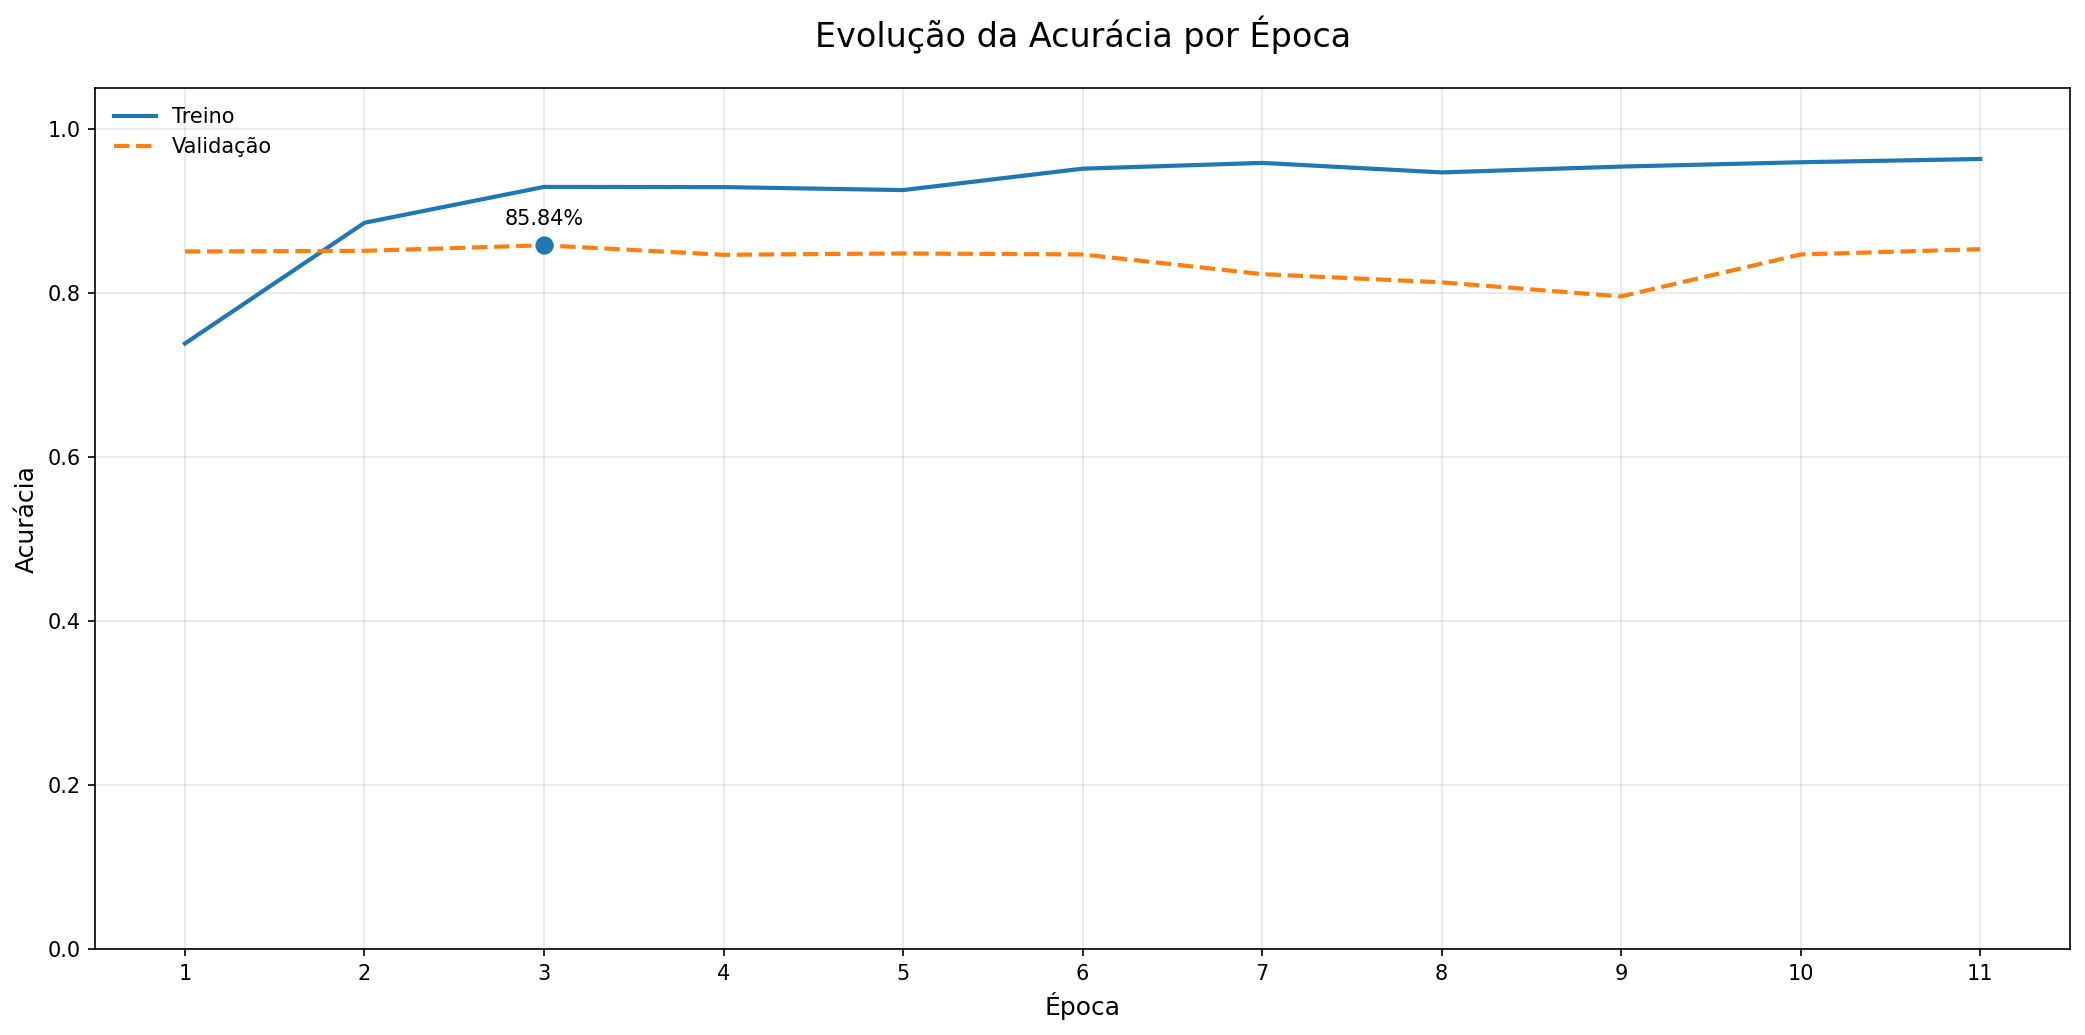

In [57]:
# ─── DADOS ──────────────────────────────────────────────────────────────────────
train_acc = history_LSTM_GL.history['accuracy']
val_acc   = history_LSTM_GL.history['val_accuracy']
epochs    = range(1, len(train_acc) + 1)

# ─── FIGURA ─────────────────────────────────────────────────────────────────────
plt.figure(figsize=(14, 7), dpi=150)

# Curva de treino
plt.plot(epochs, train_acc,
         label='Treino',
         linewidth=2)

# Curva de validação
plt.plot(epochs, val_acc,
         label='Validação',
         linewidth=2,
         linestyle='--')

# ─── REALCES ÚTEIS ──────────────────────────────────────────────────────────────
# Aponta a melhor época na validação
best_ep   = max(range(len(val_acc)), key=val_acc.__getitem__)
best_val  = val_acc[best_ep]
plt.scatter(best_ep + 1, best_val, s=60, zorder=5)
plt.text(best_ep + 1, best_val + 0.02,
         f'{best_val:.2%}',
         ha='center', va='bottom', fontsize=10)

# ─── ESTILO GERAL ───────────────────────────────────────────────────────────────
plt.title('Evolução da Acurácia por Época', fontsize=16, pad=20)
plt.xlabel('Época', fontsize=12)
plt.ylabel('Acurácia', fontsize=12)
plt.xticks(epochs)              # mostra todas as épocas no eixo-x
plt.ylim(0, 1.05)               # garante visibilidade até 100 %
plt.grid(alpha=0.3)             # grid suave
plt.legend(frameon=False)       # sem moldura no legend
plt.tight_layout()              # encaixa tudo

plt.show()





## LeCun

In [58]:
tf.keras.backend.clear_session()
tf.random.set_seed(42)

In [59]:
LSTM_LE= Sequential()
LSTM_LE.add(Embedding(max_features, 128, input_length=max_length, input_shape=X_train.shape[1:]))
LSTM_LE.add(LSTM(64, return_sequences=True,activation="tanh", kernel_initializer=initializer_3))
LSTM_LE.add(LSTM(64, return_sequences=False,activation="tanh", kernel_initializer=initializer_3))
LSTM_LE.add(Dense(1, activation='sigmoid'))

LSTM_LE.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 500, 128)       │     1,280,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 500, 64)        │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,362,497 (5.20 MB)

 Trainable params: 1,362,497 (5.20 MB)

 Non-trainable params: 0 (0.00 B)

In [60]:
early_stopping= EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
Optimizer= Adam(learning_rate=0.001)

LSTM_LE.compile(loss='binary_crossentropy', 
               optimizer=Optimizer, 
               metrics=['accuracy'])

In [61]:
history_LSTM_LE= LSTM_LE.fit(X_train, y_train, 
                           epochs=500, 
                           batch_size=256, 
                           validation_split=0.2, 
                           callbacks=[early_stopping], 
                           verbose=1)

Epoch 1/500
79/79 ━━━━━━━━━━━━━━━━━━━━ 100s 1s/step - accuracy: 0.6566 - loss: 0.5921 - val_accuracy: 0.8312 - val_loss: 0.3851
Epoch 2/500
79/79 ━━━━━━━━━━━━━━━━━━━━ 101s 1s/step - accuracy: 0.8687 - loss: 0.3117 - val_accuracy: 0.8786 - val_loss: 0.2944
Epoch 3/500
79/79 ━━━━━━━━━━━━━━━━━━━━ 101s 1s/step - accuracy: 0.9223 - loss: 0.2118 - val_accuracy: 0.8682 - val_loss: 0.3266
Epoch 4/500
79/79 ━━━━━━━━━━━━━━━━━━━━ 102s 1s/step - accuracy: 0.9272 - loss: 0.1923 - val_accuracy: 0.8454 - val_loss: 0.3601
Epoch 5/500
79/79 ━━━━━━━━━━━━━━━━━━━━ 102s 1s/step - accuracy: 0.9276 - loss: 0.1813 - val_accuracy: 0.8560 - val_loss: 0.3417
Epoch 6/500
79/79 ━━━━━━━━━━━━━━━━━━━━ 103s 1s/step - accuracy: 0.9430 - loss: 0.1572 - val_accuracy: 0.8084 - val_loss: 0.4613
Epoch 7/500
79/79 ━━━━━━━━━━━━━━━━━━━━ 103s 1s/step - accuracy: 0.9167 - loss: 0.2035 - val_accuracy: 0.8780 - val_loss: 0.3388
Epoch 8/500
79/79 ━━━━━━━━━━━━━━━━━━━━ 102s 1s/step - accuracy: 0.9601 - loss: 0.1095 - val_accuracy: 0.

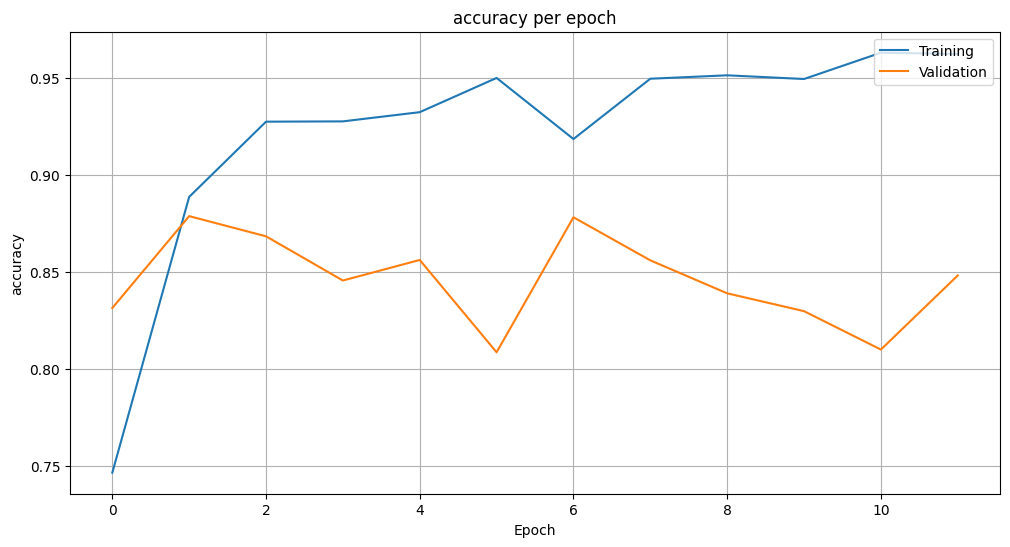

In [62]:
plt.figure(figsize=(12, 6))
plt.plot(history_LSTM_LE.history['accuracy'])
plt.plot(history_LSTM_LE.history['val_accuracy'])
plt.title('accuracy per epoch')
plt.ylabel('accuracy')
plt.xlabel('Epoch')
plt.legend(['Training', 'Validation'], loc='upper right')
plt.grid()
plt.show()

In [63]:
LSTM_LE.evaluate(X_test, y_test)

782/782 ━━━━━━━━━━━━━━━━━━━━ 38s 49ms/step - accuracy: 0.8714 - loss: 0.3073


[0.30421900749206543, 0.872439980506897]

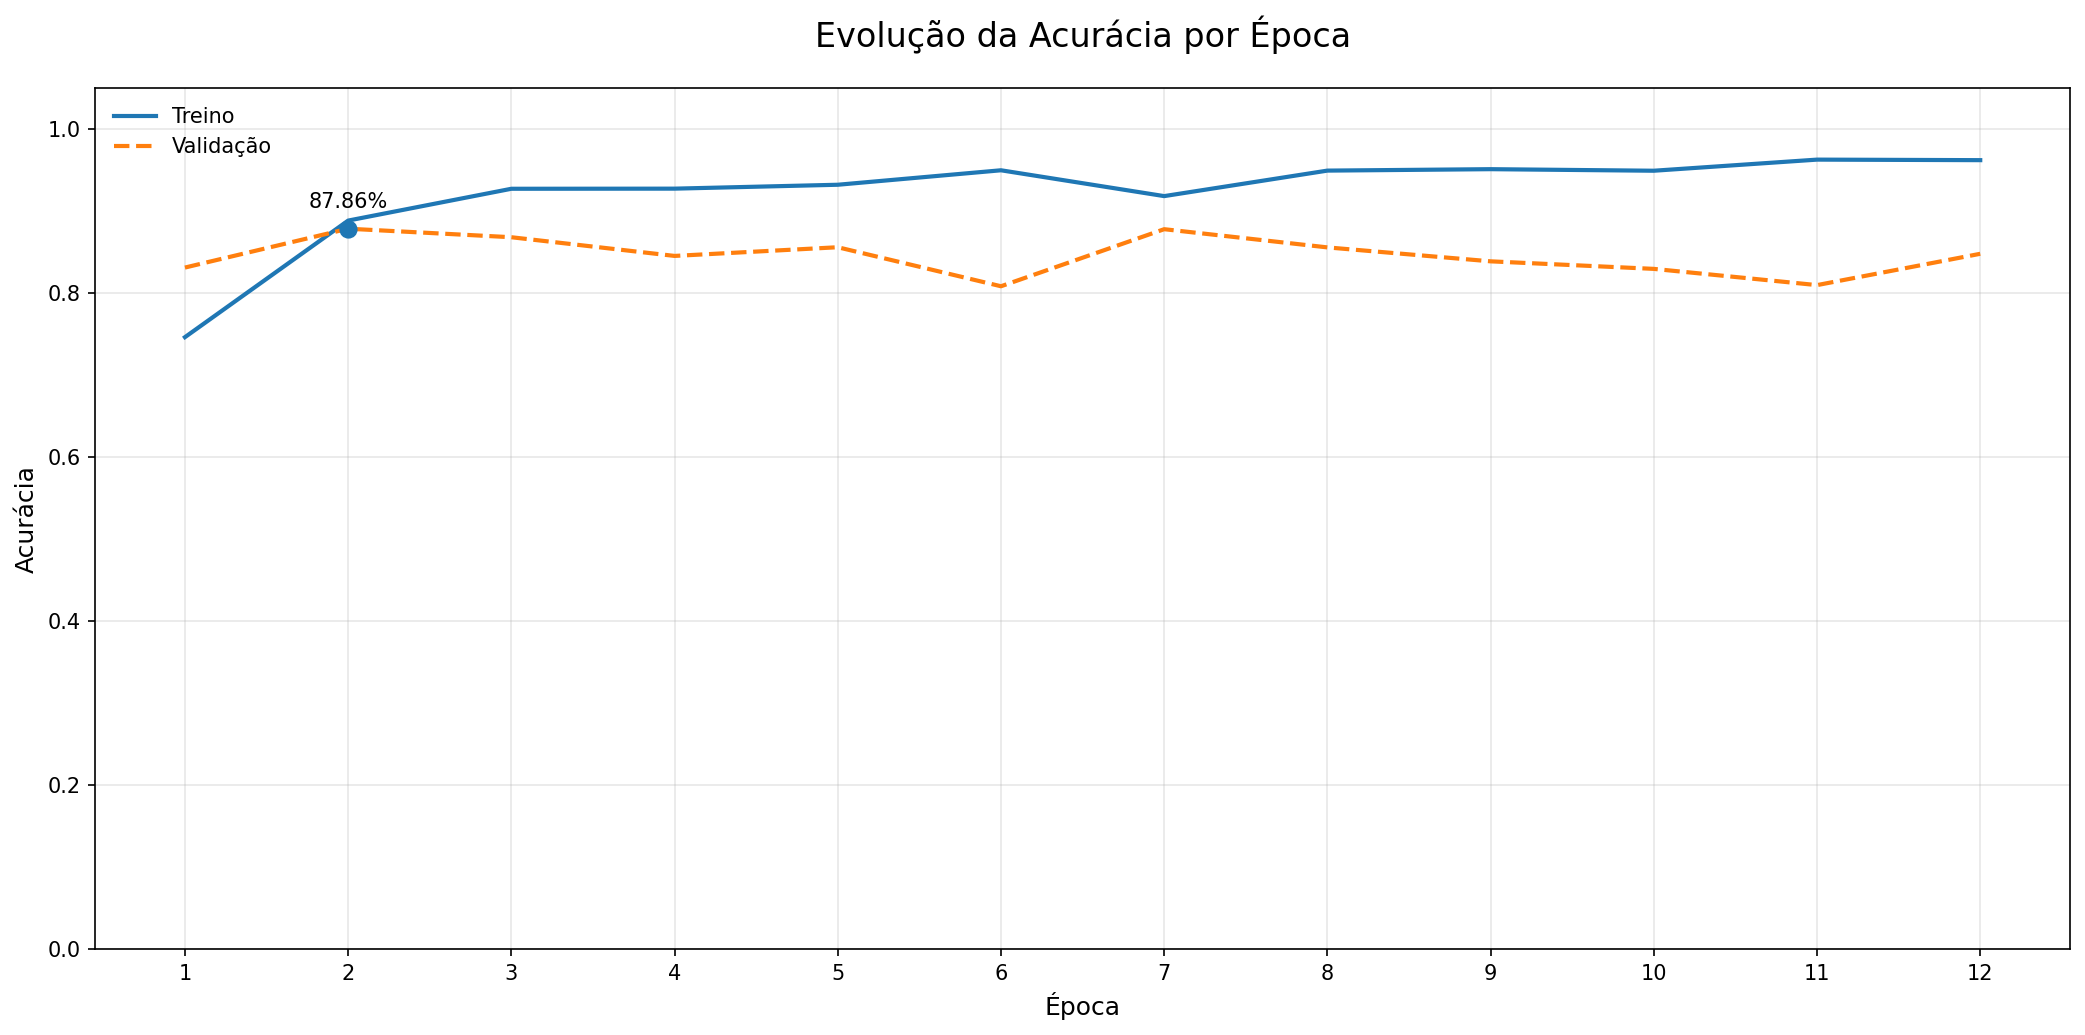

In [64]:
# ─── DADOS ──────────────────────────────────────────────────────────────────────
train_acc = history_LSTM_LE.history['accuracy']
val_acc   = history_LSTM_LE.history['val_accuracy']
epochs    = range(1, len(train_acc) + 1)

# ─── FIGURA ─────────────────────────────────────────────────────────────────────
plt.figure(figsize=(14, 7), dpi=150)

# Curva de treino
plt.plot(epochs, train_acc,
         label='Treino',
         linewidth=2)

# Curva de validação
plt.plot(epochs, val_acc,
         label='Validação',
         linewidth=2,
         linestyle='--')

# ─── REALCES ÚTEIS ──────────────────────────────────────────────────────────────
# Aponta a melhor época na validação
best_ep   = max(range(len(val_acc)), key=val_acc.__getitem__)
best_val  = val_acc[best_ep]
plt.scatter(best_ep + 1, best_val, s=60, zorder=5)
plt.text(best_ep + 1, best_val + 0.02,
         f'{best_val:.2%}',
         ha='center', va='bottom', fontsize=10)

# ─── ESTILO GERAL ───────────────────────────────────────────────────────────────
plt.title('Evolução da Acurácia por Época', fontsize=16, pad=20)
plt.xlabel('Época', fontsize=12)
plt.ylabel('Acurácia', fontsize=12)
plt.xticks(epochs)              # mostra todas as épocas no eixo-x
plt.ylim(0, 1.05)               # garante visibilidade até 100 %
plt.grid(alpha=0.3)             # grid suave
plt.legend(frameon=False)       # sem moldura no legend
plt.tight_layout()              # encaixa tudo

plt.show()


# GRU

## HE

In [65]:
tf.keras.backend.clear_session()
tf.random.set_seed(42)

In [66]:
GRU_HE= Sequential()
GRU_HE.add(Embedding(max_features, 128, input_length=max_length, input_shape=X_train.shape[1:]))
GRU_HE.add(GRU(64, return_sequences=True,activation="relu", kernel_initializer=initializer_1))
GRU_HE.add(GRU(64, return_sequences=False,activation="relu", kernel_initializer=initializer_1))
GRU_HE.add(Dense(1, activation='sigmoid'))

GRU_HE.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 500, 128)       │     1,280,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru (GRU)                       │ (None, 500, 64)        │        37,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_1 (GRU)                     │ (None, 64)             │        24,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,342,273 (5.12 MB)

 Trainable params: 1,342,273 (5.12 MB)

 Non-trainable params: 0 (0.00 B)

In [67]:
early_stopping= EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

Optimizer= Adam(learning_rate=0.001)

GRU_HE.compile(loss='binary_crossentropy', 
               optimizer=Optimizer, 
               metrics=['accuracy'])

In [68]:
history_GRU_HE= GRU_HE.fit(X_train, y_train, 
                           epochs=500, 
                           batch_size=256, 
                           validation_split=0.2, 
                           callbacks=[early_stopping], 
                           verbose=1)

Epoch 1/500
79/79 ━━━━━━━━━━━━━━━━━━━━ 129s 2s/step - accuracy: 0.5898 - loss: 0.8179 - val_accuracy: 0.7246 - val_loss: 0.5434
Epoch 2/500
79/79 ━━━━━━━━━━━━━━━━━━━━ 130s 2s/step - accuracy: 0.7768 - loss: 0.4693 - val_accuracy: 0.7490 - val_loss: 0.4861
Epoch 3/500
79/79 ━━━━━━━━━━━━━━━━━━━━ 128s 2s/step - accuracy: 0.8510 - loss: 0.3556 - val_accuracy: 0.8448 - val_loss: 0.3672
Epoch 4/500
79/79 ━━━━━━━━━━━━━━━━━━━━ 128s 2s/step - accuracy: 0.9038 - loss: 0.2392 - val_accuracy: 0.8382 - val_loss: 0.4158
Epoch 5/500
79/79 ━━━━━━━━━━━━━━━━━━━━ 128s 2s/step - accuracy: 0.9299 - loss: 0.1817 - val_accuracy: 0.8466 - val_loss: 0.3993
Epoch 6/500
79/79 ━━━━━━━━━━━━━━━━━━━━ 129s 2s/step - accuracy: 0.9308 - loss: 0.1824 - val_accuracy: 0.8434 - val_loss: 0.4054
Epoch 7/500
79/79 ━━━━━━━━━━━━━━━━━━━━ 127s 2s/step - accuracy: 0.9526 - loss: 0.1300 - val_accuracy: 0.8548 - val_loss: 0.4672
Epoch 8/500
79/79 ━━━━━━━━━━━━━━━━━━━━ 130s 2s/step - accuracy: 0.9779 - loss: 0.0782 - val_accuracy: 0.

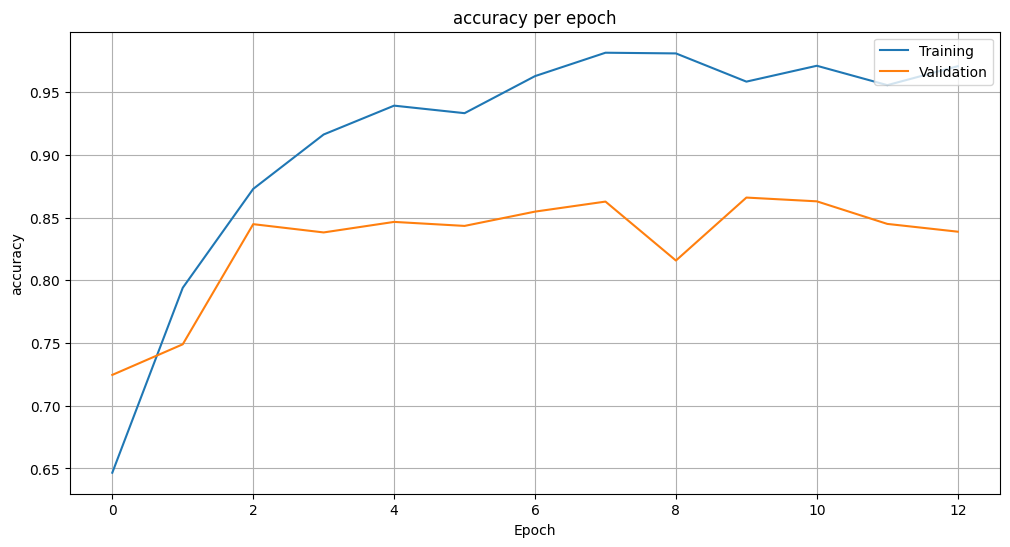

In [69]:
plt.figure(figsize=(12, 6))
plt.plot(history_GRU_HE.history['accuracy'])
plt.plot(history_GRU_HE.history['val_accuracy'])
plt.title('accuracy per epoch')
plt.ylabel('accuracy')
plt.xlabel('Epoch')
plt.legend(['Training', 'Validation'], loc='upper right')
plt.grid()
plt.show()

In [70]:
GRU_HE.evaluate(X_test, y_test)

782/782 ━━━━━━━━━━━━━━━━━━━━ 35s 45ms/step - accuracy: 0.8331 - loss: 0.3879


[0.3798436224460602, 0.8370000123977661]

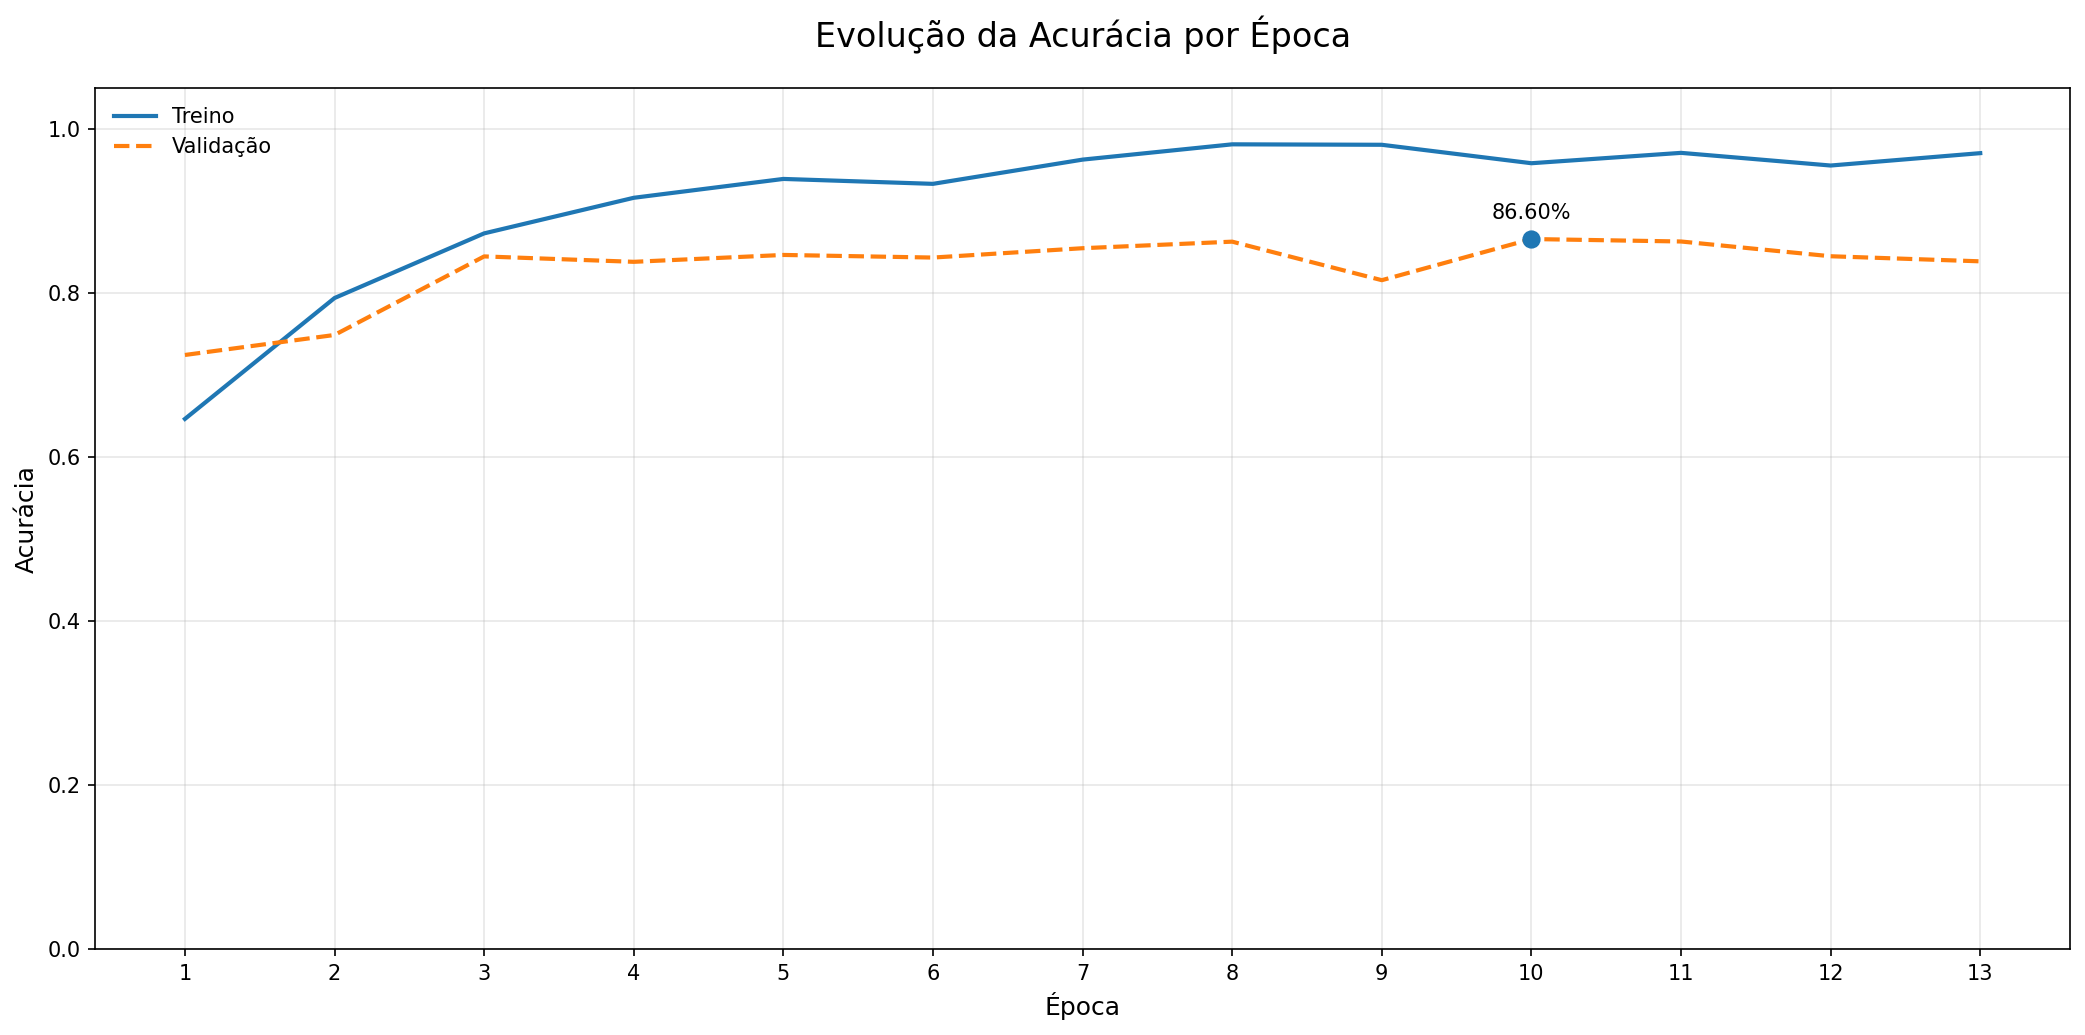

In [71]:
# ─── DADOS ──────────────────────────────────────────────────────────────────────
train_acc = history_GRU_HE.history['accuracy']
val_acc   = history_GRU_HE.history['val_accuracy']
epochs    = range(1, len(train_acc) + 1)

# ─── FIGURA ─────────────────────────────────────────────────────────────────────
plt.figure(figsize=(14, 7), dpi=150)

# Curva de treino
plt.plot(epochs, train_acc,
         label='Treino',
         linewidth=2)

# Curva de validação
plt.plot(epochs, val_acc,
         label='Validação',
         linewidth=2,
         linestyle='--')

# ─── REALCES ÚTEIS ──────────────────────────────────────────────────────────────
# Aponta a melhor época na validação
best_ep   = max(range(len(val_acc)), key=val_acc.__getitem__)
best_val  = val_acc[best_ep]
plt.scatter(best_ep + 1, best_val, s=60, zorder=5)
plt.text(best_ep + 1, best_val + 0.02,
         f'{best_val:.2%}',
         ha='center', va='bottom', fontsize=10)

# ─── ESTILO GERAL ───────────────────────────────────────────────────────────────
plt.title('Evolução da Acurácia por Época', fontsize=16, pad=20)
plt.xlabel('Época', fontsize=12)
plt.ylabel('Acurácia', fontsize=12)
plt.xticks(epochs)              # mostra todas as épocas no eixo-x
plt.ylim(0, 1.05)               # garante visibilidade até 100 %
plt.grid(alpha=0.3)             # grid suave
plt.legend(frameon=False)       # sem moldura no legend
plt.tight_layout()              # encaixa tudo

plt.show()


## GLorot

In [72]:
tf.keras.backend.clear_session()
tf.random.set_seed(42)

In [73]:
GRU_GL= Sequential()
GRU_GL.add(Embedding(max_features, 128, input_length=max_length, input_shape=X_train.shape[1:]))
GRU_GL.add(GRU(64, return_sequences=True,activation="tanh", kernel_initializer=initializer_2))
GRU_GL.add(GRU(64, return_sequences=False,activation="tanh", kernel_initializer=initializer_2))
GRU_GL.add(Dense(1, activation='sigmoid'))

GRU_GL.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 500, 128)       │     1,280,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru (GRU)                       │ (None, 500, 64)        │        37,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_1 (GRU)                     │ (None, 64)             │        24,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,342,273 (5.12 MB)

 Trainable params: 1,342,273 (5.12 MB)

 Non-trainable params: 0 (0.00 B)

In [74]:
early_stopping= EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
Optimizer= Adam(learning_rate=0.001)

GRU_GL.compile(loss='binary_crossentropy', 
               optimizer=Optimizer, 
               metrics=['accuracy'])

In [75]:
history_GRU_GL= GRU_GL.fit(X_train, y_train, 
                           epochs=500, 
                           batch_size=256, 
                           validation_split=0.2, 
                           callbacks=[early_stopping], 
                           verbose=1)

Epoch 1/500
79/79 ━━━━━━━━━━━━━━━━━━━━ 114s 1s/step - accuracy: 0.6153 - loss: 0.6323 - val_accuracy: 0.7540 - val_loss: 0.4959
Epoch 2/500
79/79 ━━━━━━━━━━━━━━━━━━━━ 110s 1s/step - accuracy: 0.8131 - loss: 0.4102 - val_accuracy: 0.8584 - val_loss: 0.3406
Epoch 3/500
79/79 ━━━━━━━━━━━━━━━━━━━━ 112s 1s/step - accuracy: 0.8922 - loss: 0.2564 - val_accuracy: 0.8718 - val_loss: 0.3170
Epoch 4/500
79/79 ━━━━━━━━━━━━━━━━━━━━ 112s 1s/step - accuracy: 0.9294 - loss: 0.1827 - val_accuracy: 0.7670 - val_loss: 0.5943
Epoch 5/500
79/79 ━━━━━━━━━━━━━━━━━━━━ 113s 1s/step - accuracy: 0.9060 - loss: 0.2310 - val_accuracy: 0.7996 - val_loss: 0.4710
Epoch 6/500
79/79 ━━━━━━━━━━━━━━━━━━━━ 111s 1s/step - accuracy: 0.9282 - loss: 0.1865 - val_accuracy: 0.8522 - val_loss: 0.4058
Epoch 7/500
79/79 ━━━━━━━━━━━━━━━━━━━━ 112s 1s/step - accuracy: 0.9482 - loss: 0.1366 - val_accuracy: 0.8416 - val_loss: 0.4061
Epoch 8/500
79/79 ━━━━━━━━━━━━━━━━━━━━ 112s 1s/step - accuracy: 0.9452 - loss: 0.1446 - val_accuracy: 0.

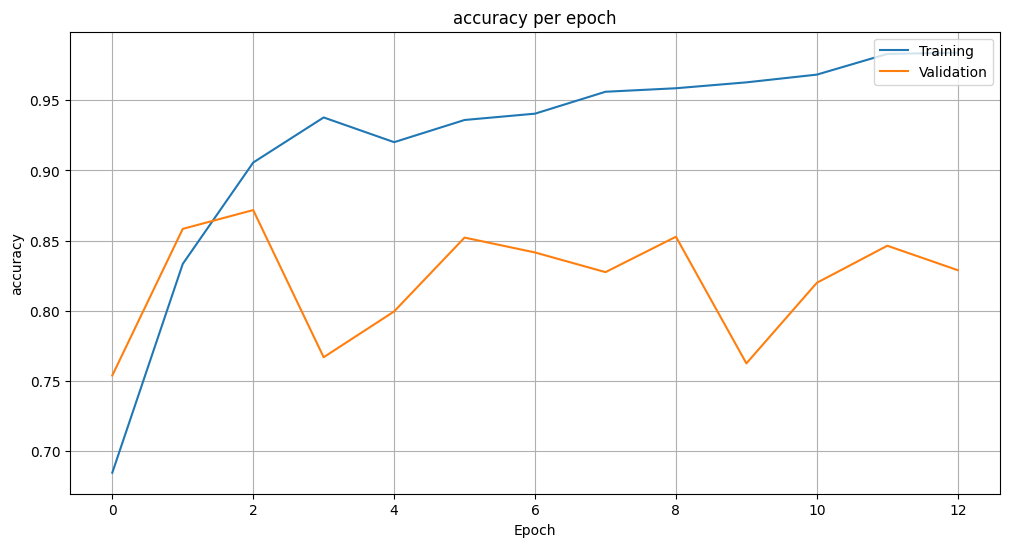

In [76]:
plt.figure(figsize=(12, 6))
plt.plot(history_GRU_GL.history['accuracy'])
plt.plot(history_GRU_GL.history['val_accuracy'])
plt.title('accuracy per epoch')
plt.ylabel('accuracy')
plt.xlabel('Epoch')
plt.legend(['Training', 'Validation'], loc='upper right')
plt.grid()
plt.show()

In [77]:
GRU_GL.evaluate(X_test, y_test)

782/782 ━━━━━━━━━━━━━━━━━━━━ 34s 44ms/step - accuracy: 0.8560 - loss: 0.3425


[0.3409421443939209, 0.8580399751663208]

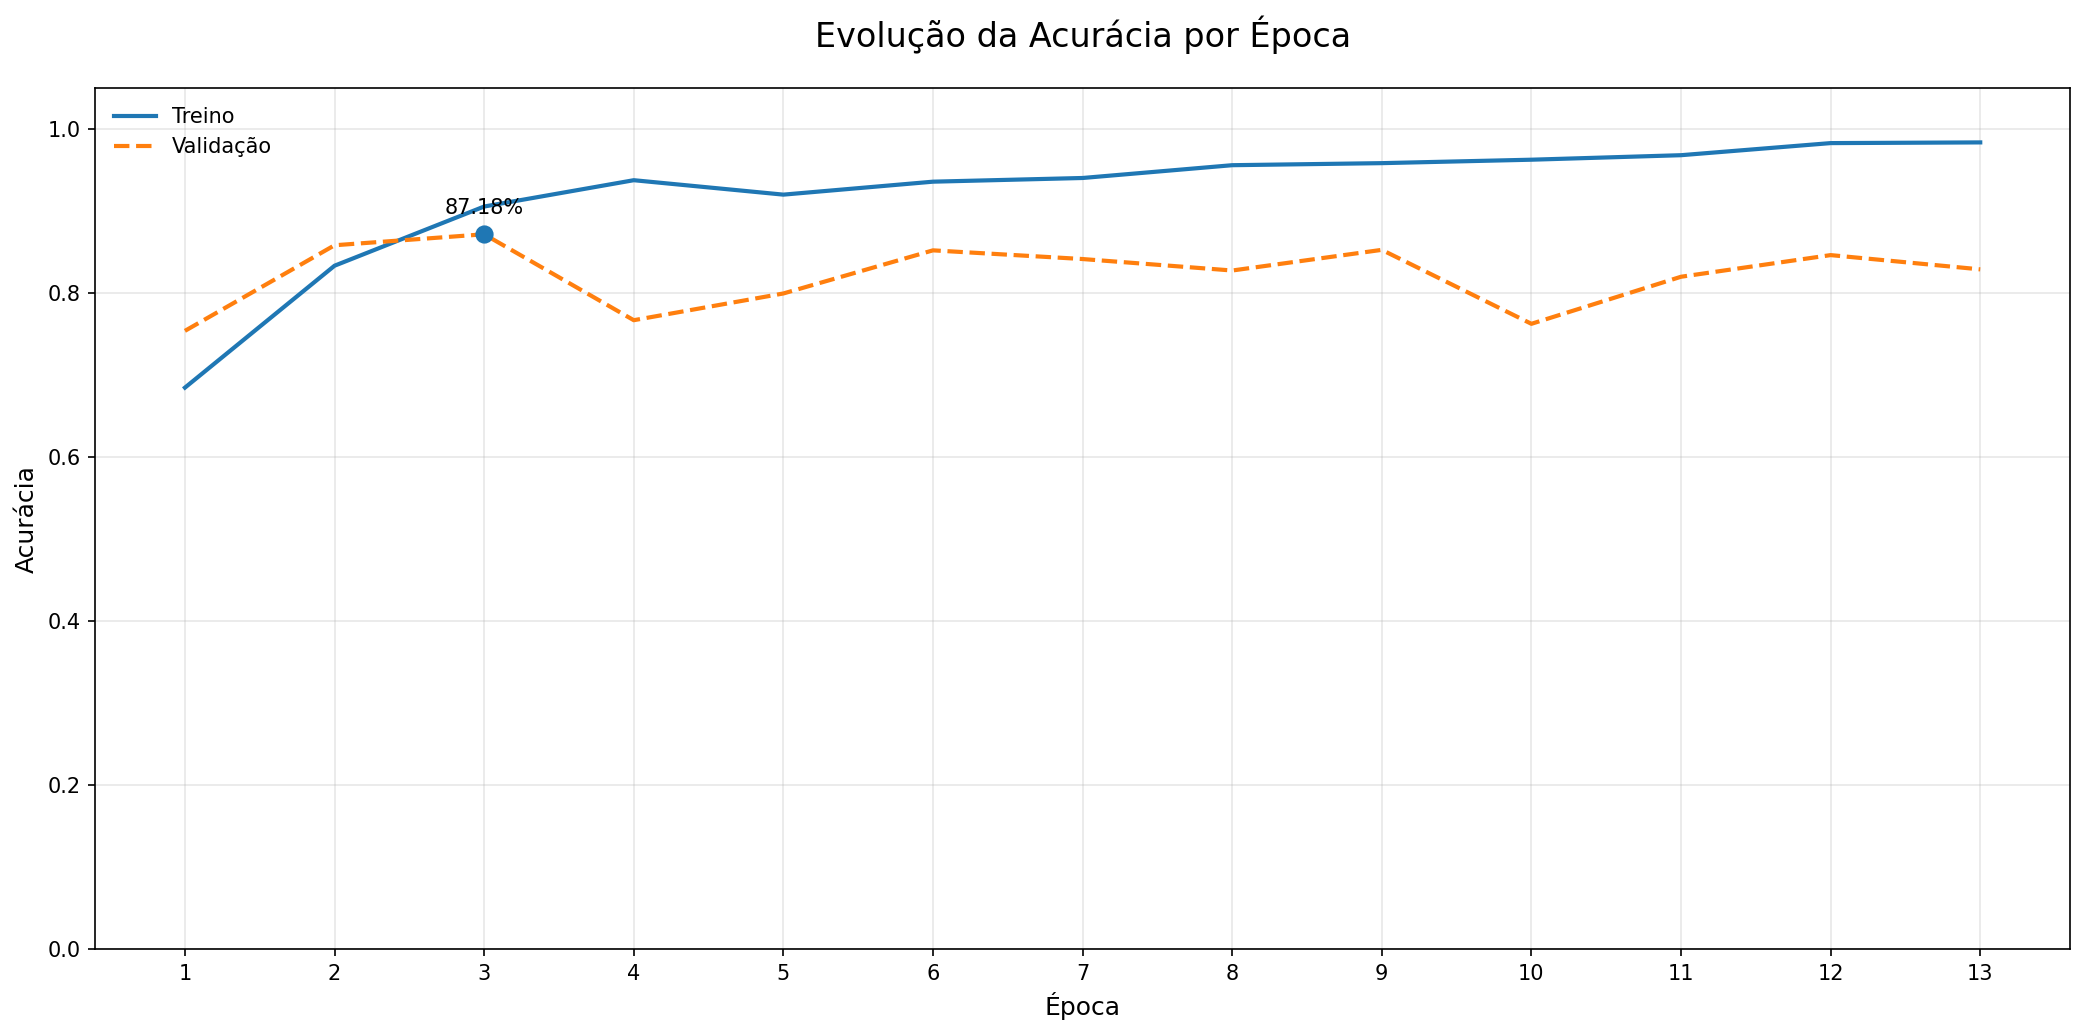

In [78]:
# ─── DADOS ──────────────────────────────────────────────────────────────────────
train_acc = history_GRU_GL.history['accuracy']
val_acc   = history_GRU_GL.history['val_accuracy']
epochs    = range(1, len(train_acc) + 1)

# ─── FIGURA ─────────────────────────────────────────────────────────────────────
plt.figure(figsize=(14, 7), dpi=150)

# Curva de treino
plt.plot(epochs, train_acc,
         label='Treino',
         linewidth=2)

# Curva de validação
plt.plot(epochs, val_acc,
         label='Validação',
         linewidth=2,
         linestyle='--')

# ─── REALCES ÚTEIS ──────────────────────────────────────────────────────────────
# Aponta a melhor época na validação
best_ep   = max(range(len(val_acc)), key=val_acc.__getitem__)
best_val  = val_acc[best_ep]
plt.scatter(best_ep + 1, best_val, s=60, zorder=5)
plt.text(best_ep + 1, best_val + 0.02,
         f'{best_val:.2%}',
         ha='center', va='bottom', fontsize=10)

# ─── ESTILO GERAL ───────────────────────────────────────────────────────────────
plt.title('Evolução da Acurácia por Época', fontsize=16, pad=20)
plt.xlabel('Época', fontsize=12)
plt.ylabel('Acurácia', fontsize=12)
plt.xticks(epochs)              # mostra todas as épocas no eixo-x
plt.ylim(0, 1.05)               # garante visibilidade até 100 %
plt.grid(alpha=0.3)             # grid suave
plt.legend(frameon=False)       # sem moldura no legend
plt.tight_layout()              # encaixa tudo

plt.show()


## LeCun

In [79]:
tf.keras.backend.clear_session()
tf.random.set_seed(42)

In [80]:
GRU_LE= Sequential()
GRU_LE.add(Embedding(max_features, 128, input_length=max_length, input_shape=X_train.shape[1:]))
GRU_LE.add(GRU(64, return_sequences=True,activation="tanh", kernel_initializer=initializer_3))
GRU_LE.add(GRU(64, return_sequences=False,activation="tanh", kernel_initializer=initializer_3))
GRU_LE.add(Dense(1, activation='sigmoid'))

GRU_LE.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 500, 128)       │     1,280,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru (GRU)                       │ (None, 500, 64)        │        37,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_1 (GRU)                     │ (None, 64)             │        24,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,342,273 (5.12 MB)

 Trainable params: 1,342,273 (5.12 MB)

 Non-trainable params: 0 (0.00 B)

In [81]:
early_stopping= EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
Optimizer= Adam(learning_rate=0.001)

GRU_LE.compile(loss='binary_crossentropy', 
               optimizer=Optimizer, 
               metrics=['accuracy'])

In [82]:
history_GRU_LE= GRU_LE.fit(X_train, y_train, 
                           epochs=500, 
                           batch_size=256, 
                           validation_split=0.2, 
                           callbacks=[early_stopping], 
                           verbose=1)

Epoch 1/500
79/79 ━━━━━━━━━━━━━━━━━━━━ 124s 2s/step - accuracy: 0.6177 - loss: 0.6216 - val_accuracy: 0.8276 - val_loss: 0.3881
Epoch 2/500
79/79 ━━━━━━━━━━━━━━━━━━━━ 120s 2s/step - accuracy: 0.8484 - loss: 0.3460 - val_accuracy: 0.8620 - val_loss: 0.3393
Epoch 3/500
79/79 ━━━━━━━━━━━━━━━━━━━━ 122s 2s/step - accuracy: 0.8978 - loss: 0.2499 - val_accuracy: 0.8520 - val_loss: 0.3494
Epoch 4/500
79/79 ━━━━━━━━━━━━━━━━━━━━ 123s 2s/step - accuracy: 0.9138 - loss: 0.2190 - val_accuracy: 0.8470 - val_loss: 0.3665
Epoch 5/500
79/79 ━━━━━━━━━━━━━━━━━━━━ 125s 2s/step - accuracy: 0.9254 - loss: 0.1947 - val_accuracy: 0.8652 - val_loss: 0.3535
Epoch 6/500
79/79 ━━━━━━━━━━━━━━━━━━━━ 126s 2s/step - accuracy: 0.9359 - loss: 0.1686 - val_accuracy: 0.8592 - val_loss: 0.3787
Epoch 7/500
79/79 ━━━━━━━━━━━━━━━━━━━━ 127s 2s/step - accuracy: 0.9535 - loss: 0.1294 - val_accuracy: 0.7916 - val_loss: 0.5983
Epoch 8/500
79/79 ━━━━━━━━━━━━━━━━━━━━ 127s 2s/step - accuracy: 0.9211 - loss: 0.1985 - val_accuracy: 0.

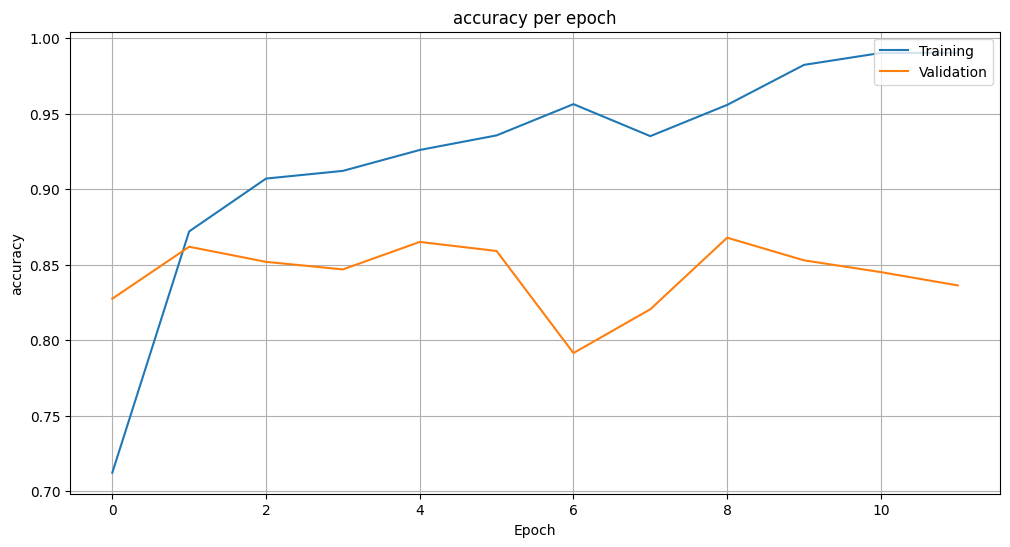

In [83]:
plt.figure(figsize=(12, 6))
plt.plot(history_GRU_LE.history['accuracy'])
plt.plot(history_GRU_LE.history['val_accuracy'])
plt.title('accuracy per epoch')
plt.ylabel('accuracy')
plt.xlabel('Epoch')
plt.legend(['Training', 'Validation'], loc='upper right')
plt.grid()
plt.show()

In [84]:
GRU_LE.evaluate(X_test, y_test)

782/782 ━━━━━━━━━━━━━━━━━━━━ 35s 44ms/step - accuracy: 0.8587 - loss: 0.3519


[0.35275694727897644, 0.8570799827575684]

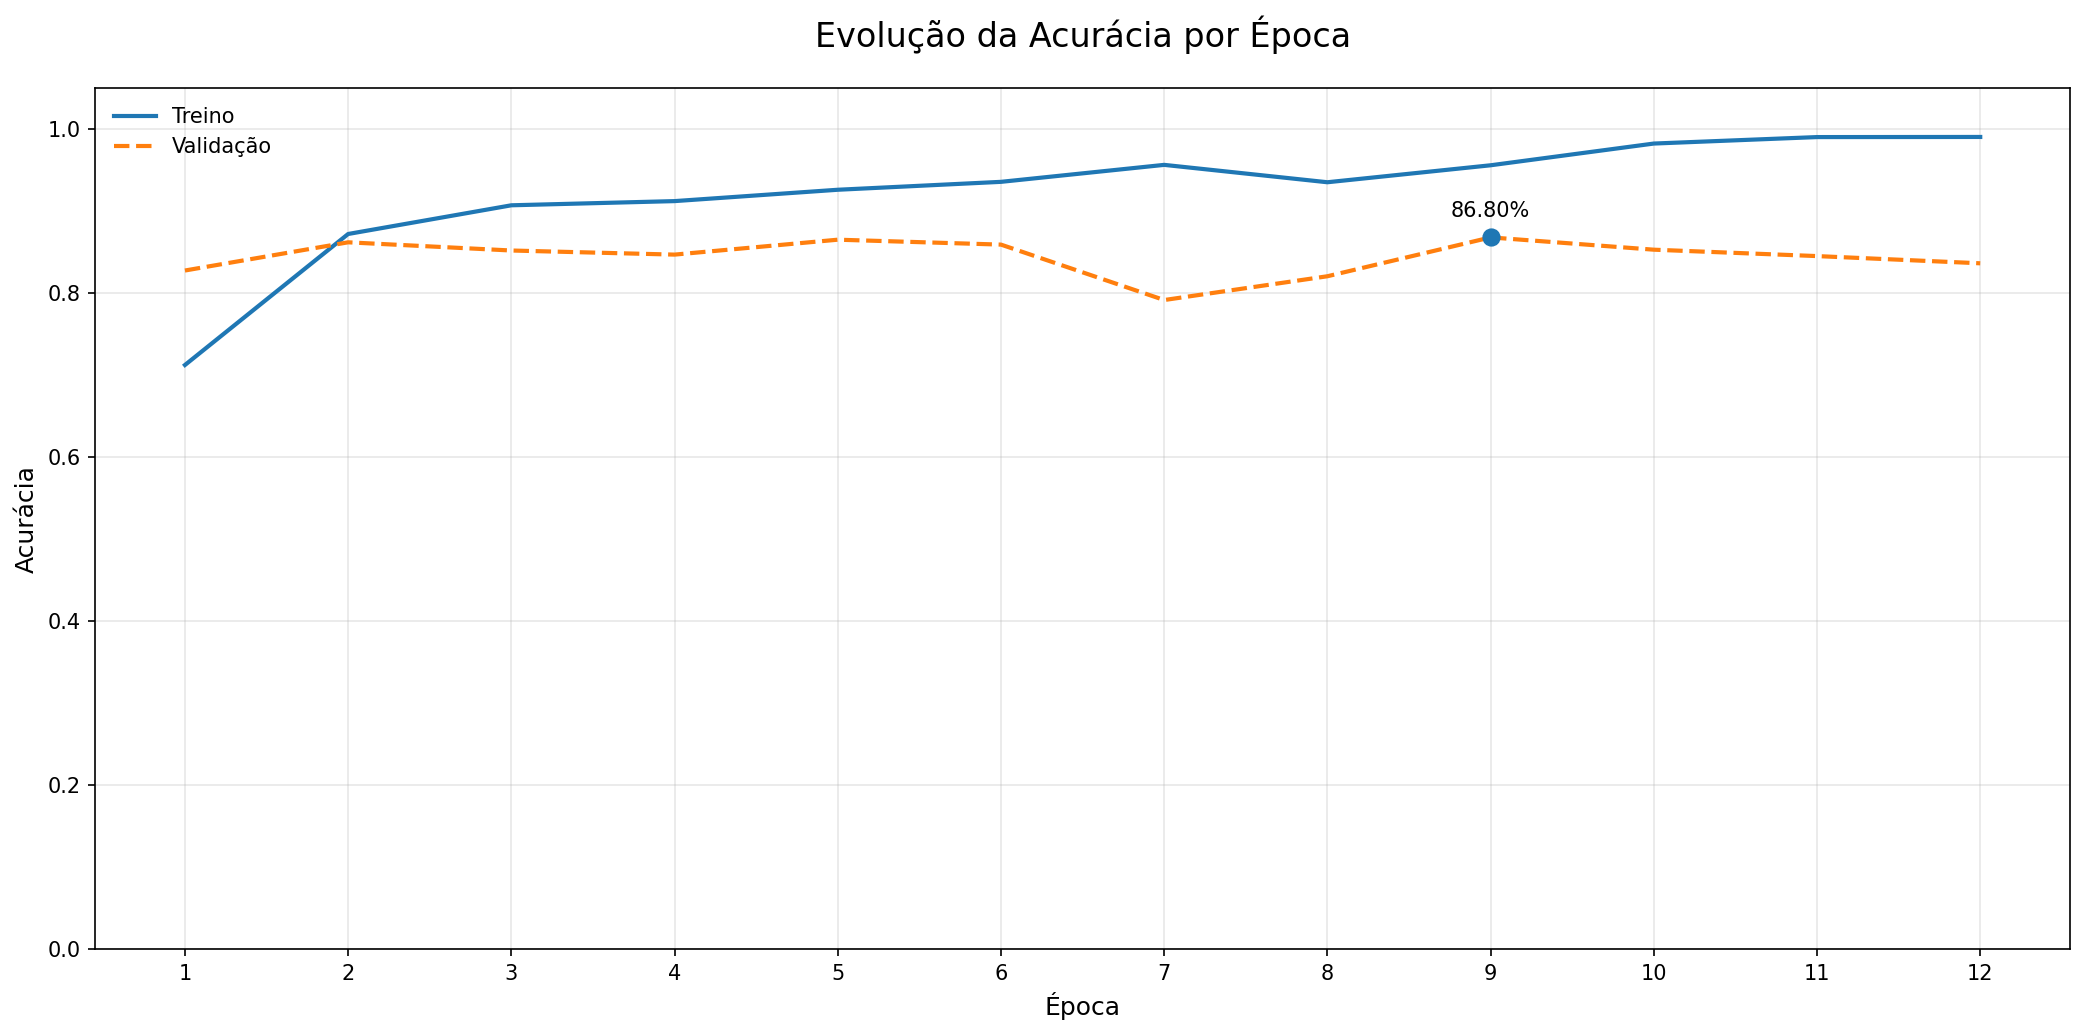

In [85]:
# ─── DADOS ──────────────────────────────────────────────────────────────────────
train_acc = history_GRU_LE.history['accuracy']
val_acc   = history_GRU_LE.history['val_accuracy']
epochs    = range(1, len(train_acc) + 1)

# ─── FIGURA ─────────────────────────────────────────────────────────────────────
plt.figure(figsize=(14, 7), dpi=150)

# Curva de treino
plt.plot(epochs, train_acc,
         label='Treino',
         linewidth=2)

# Curva de validação
plt.plot(epochs, val_acc,
         label='Validação',
         linewidth=2,
         linestyle='--')

# ─── REALCES ÚTEIS ──────────────────────────────────────────────────────────────
# Aponta a melhor época na validação
best_ep   = max(range(len(val_acc)), key=val_acc.__getitem__)
best_val  = val_acc[best_ep]
plt.scatter(best_ep + 1, best_val, s=60, zorder=5)
plt.text(best_ep + 1, best_val + 0.02,
         f'{best_val:.2%}',
         ha='center', va='bottom', fontsize=10)

# ─── ESTILO GERAL ───────────────────────────────────────────────────────────────
plt.title('Evolução da Acurácia por Época', fontsize=16, pad=20)
plt.xlabel('Época', fontsize=12)
plt.ylabel('Acurácia', fontsize=12)
plt.xticks(epochs)              # mostra todas as épocas no eixo-x
plt.ylim(0, 1.05)               # garante visibilidade até 100 %
plt.grid(alpha=0.3)             # grid suave
plt.legend(frameon=False)       # sem moldura no legend
plt.tight_layout()              # encaixa tudo

plt.show()
